# Woche 1 – Checklist & Roadmap
This week is all about setting up your workspace and reducing the raw data to a manageable portion with a focus on the Guayas province.

## Load Data 

In [1]:
# Zentralisierte Imports
import pandas as pd
import os
import numpy as np
import warnings
import re 
from typing import Dict, List, Callable, Union
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split ,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler ,MinMaxScaler
import mlflow
import mlflow.xgboost
import shutil 
from mlflow.models.signature import infer_signature 
from joblib import dump, load
from datetime import datetime
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm
from tqdm.keras import TqdmCallback 
from IPython.display import display
import time
import gc
import sys

# Warnungen ignorieren
warnings.filterwarnings('ignore')

# Pandas-Anzeigeoptionen 'fals ich was gucken möchte zwischen gelagert'
#pd.set_option('display.width', 1000)
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_colwidth', None)

# Datenpfad
DATA_PATH = "Sempel_data"

# Laden der kleineren CSV-Dateien
df_holiday_events = pd.read_csv(os.path.join(DATA_PATH, "holiday_events.csv"))
df_items = pd.read_csv(os.path.join(DATA_PATH, "items.csv"))
df_oil = pd.read_csv(os.path.join(DATA_PATH, "oil.csv"))
df_stores = pd.read_csv(os.path.join(DATA_PATH, "stores.csv"))
df_transactions = pd.read_csv(os.path.join(DATA_PATH, "transactions.csv"))

print("All smaller csv files loaded successfully.")


All smaller csv files loaded successfully.


In [2]:
# Pattern: Load and slim down the main file (Guayas filtering and downsampling to 300000)
train_csv_path = os.path.join(DATA_PATH, "train.csv")

chunk_size = 10**6
filtered_chunks = []

# 1. Filter Store_IDs for Guayas
guayas_stores = df_stores[df_stores['state'] == 'Guayas']['store_nbr'].unique()

# 2. Load and filter train.csv in chunks
for chunk in pd.read_csv(train_csv_path, chunksize=chunk_size, dtype={'onpromotion': str}):
    chunk_filtered = chunk[chunk['store_nbr'].isin(guayas_stores)]
    filtered_chunks.append(chunk_filtered)

df_train_guayas = pd.concat(filtered_chunks)

# 3. Downsampling by percentage (0.01% for minimal testing)
df_train = df_train_guayas.sample(n=min(300000, len(df_train_guayas)), random_state=42).copy()

# CORRECTION: Convert 'date' column to datetime
df_train['date'] = pd.to_datetime(df_train['date'])

print("train.csv processed successfully.")
print(f"Original Guayas rows (approx.): {df_train_guayas.shape[0]}")
print(f"Final dataframe df_train shape (0.01% Sample): {df_train.shape}")
print(f"✅ df_train now contains {df_train.shape[0]} rows. The large DataFrame has been overwritten.")
df_train.head()


train.csv processed successfully.
Original Guayas rows (approx.): 22941656
Final dataframe df_train shape (0.01% Sample): (300000, 6)
✅ df_train now contains 300000 rows. The large DataFrame has been overwritten.


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
36402992,36402992,2014-12-01,26,1696038,2.234,False
40318340,40318340,2015-01-31,27,804974,18.000,False
2631489,2631489,2013-03-06,51,838216,45.000,NaN
24252889,24252889,2014-05-23,27,207857,6.000,False
46434803,46434803,2015-05-10,29,679926,4.000,False


## Data Exploration & Feature Engineering (follow the same procedure as in the lectures, but now apply it to Guayas)

- Data Quality Checks
  - Missing Values: Detect and handle null values in each column.
  - Missing Calendar Days: Create a full daily index for each (store, item) and fill missing days with unit_sales = 0.
  - Outliers: Check for impossible negative values or extreme spikes in unit_sales; trim, replace, or flag if necessary.

In [3]:
import pandas as pd
import numpy as np
import re
from typing import Dict, List, Union, Callable
import warnings
import sys
from io import StringIO

# ANNAHME: df_train ist geladen.
df_TEMP = df_train

def generate_cleaning_muster(column: str, semantic_type: str) -> str:
    # Platzhalter
    return ""

def count_special_chars(text: Union[str, any]) -> int:
    if isinstance(text, str):
        # Gezählt werden alle Zeichen außer Buchstaben, Zahlen und Leerzeichen
        return len(re.findall(r'[^a-zA-Z0-9\s]', text))
    return 0

# Definition der Semantik-Analyse-Funktion (analyze_semantic_type_v4)
# ... [Ihr Code für analyze_semantic_type_v4 hier einfügen] ...
def analyze_semantic_type_v4(df_TEMP: pd.DataFrame) -> pd.DataFrame:
    """
    Klassifiziert die semantischen Datentypen der Spalten (aus Muster2).
    """
    SEMANTIC_HINTS_PRIORITY: Dict[str, Dict[str, Union[set, Callable]]] = {
        'ID': {
            'keywords': {'_id', 'session_id', 'trip_id', 'user_id', 'unique_id', 'kundennummer', 'bestellnr', 'order_id', 'artikelnummer', 'store_nbr', 'item_nbr'},
            'validation_func': lambda series: ((series.dropna().astype(str).apply(len) >= 3).any())
        },
        'Datum/Zeit': {
            'keywords': {'datum', 'zeit', 'date', 'time', 'start', 'end', 'birthdate', 'signup_date', 'check_in', 'check_out', 'departure', 'return', 'geburtstag', 'timestamp', 'creation_date', 'modified_date', 'erstellt', 'week'},
            'validation_func':lambda series: ((series.dropna().nunique() == 12 or series.dropna().nunique() == 31) or (series.dropna().apply(lambda x: isinstance(x, str)).all() and (pd.to_datetime(series.dropna(), errors='coerce').notna().all() or (series.dropna().astype(str).str.contains(r'[-_/]', na=False).any() and series.dropna().astype(str).str.contains(r'\d{4}', na=False).any())))) or (pd.api.types.is_datetime64_any_dtype(series))
        },
        'Datum/Zeit(int)': {
            'keywords': {'month','week','day'},
            'validation_func': lambda series: (series.dropna().nunique() == 12 or 6 <= series.dropna().nunique() <= 7 or series.dropna().nunique() == 31)
        },
        'Geometrisch': {
            'keywords': {'geom', 'geometry', 'shape', 'wkt', 'geojson', 'coordinates', 'location_data'},
            'validation_func': lambda series: (series.dropna().astype(str).str.contains(r'^(POINT|LINESTRING|POLYGON|MULTIPOINT|MULTILINESTRING|MULTIPOLYGON)\s*\(', regex=True, na=False).any() or series.dropna().astype(str).str.contains(r'{"type":\s*"(Point|LineString|Polygon|MultiPoint|MultiLineString|MultiPolygon)"', regex=True, na=False).any())
        },
    }
    SEMANTIC_HINTS_TEXT: Dict[str, Dict[str, Union[set, Callable]]] = {
        'Text (Kategorisch)': {
            'keywords': {'city', 'country', 'länder', 'region', 'state', 'bundesland', 'zip', 'plz', 'family'},
            'validation_func': lambda series: series.dropna().nunique() >= 2 and (pd.api.types.is_string_dtype(series.dropna()) or isinstance(series.dropna().dtype, pd.CategoricalDtype))
        },
        'Text (Gender)': {
            'keywords': {'geschlecht', 'typ', 'category', 'art', 'gender'},
            'validation_func': lambda series: series.dropna().nunique() >= 2 and (pd.api.types.is_string_dtype(series.dropna()) or isinstance(series.dropna().dtype, pd.CategoricalDtype))
        },
        'Text (object)': {
            'keywords': {'sales_method', 'airport', 'destination', 'origin', 'heimat', 'status'},
            'validation_func': lambda series: series.dropna().nunique() >= 2 and (pd.api.types.is_string_dtype(series.dropna()) or isinstance(series.dropna().dtype, pd.CategoricalDtype))
        },
        'Text (Freitext)': {
            'keywords': {'name', 'hotel', 'airline', 'beschreibung', 'kommentar', 'nachricht', 'adresse'},
            'validation_func': lambda series: pd.api.types.is_string_dtype(series.dropna()) or isinstance(series.dropna().dtype, pd.CategoricalDtype)
        },
    }
    SEMANTIC_HINTS_NUMERIC: Dict[str, Dict[str, Union[set, Callable]]] = {
        'Boolean(NaN)': {
            'keywords': {'is_invalid','missing', 'is_missing', 'has_value', 'exists', 'is_null', 'is_na', 'isnan', 'filled','is_outlier'},
            'validation_func': lambda series: (series.dropna().nunique() >= 1) and (pd.api.types.is_bool_dtype(series.dropna()) or set(series.dropna().astype(str).str.lower().str.strip().unique()).issubset({'true', 'false', '1', '0', 'ja', 'nein', 'yes', 'no', 't', 'f', 'wahr', 'falsch'}))
        },
        'Boolean': {
            'keywords': {'self_employed','is_weekend_trip', 'boolean', 'bool', 'booked', 'married', 'cancellation', 'children','discount', 'flight_booked', 'hotel_booked', 'return_flight_booked', 'is_cancelled', 'onpromotion'},
            'validation_func': lambda series: (series.dropna().nunique() <= 2) and (pd.api.types.is_bool_dtype(series.dropna()) or set(series.dropna().astype(str).str.lower().str.strip().unique()).issubset({'true', 'false', '1', '0', 'ja', 'nein', 'yes', 'no', 't', 'f', 'wahr', 'falsch'}))
        },
        'Float (Geografisch)': {
            'keywords': {'lat', 'lon', 'latitude', 'longitude'},
            'validation_func': lambda series: pd.to_numeric(series.dropna(), errors='coerce').notna().all() and (pd.to_numeric(series.dropna(), errors='coerce').astype(str).str.count(r'\.').all() or pd.api.types.is_float_dtype(series.dropna()))
        },
        'Float (Prozentsatz)': {
            'keywords': {'percent', 'pct', 'rate', 'discount', '%'},
            'validation_func': lambda series: (series.dropna().nunique() > 2) and ((pd.to_numeric(series.dropna().astype(str).str.replace('%', ''), errors='coerce').dropna().between(0, 1).all() or pd.to_numeric(series.dropna().astype(str).str.replace('%', ''), errors='coerce').dropna().between(0, 100).all()) or (pd.to_numeric(series.dropna().astype(str).str.replace('%', ''), errors='coerce').notna().all() and series.dropna().astype(str).str.replace('%', '').str.replace(',', '.').str.match(r'^\d{1,3}(\.\d{1,3})?$').all()))
        },
        'Float (Waehrung)': {
            'keywords': {'revenue','preis', 'kosten', 'betrag', 'dollar', 'euro', 'yen', 'usd', 'eur', 'fare','chf', 'gbp', 'sek', 'jpy', '€', '£', '$'},
            'validation_func': lambda series: (pd.api.types.is_numeric_dtype(series.dropna()) or pd.to_numeric(series.dropna().astype(str).str.replace(',', '.'), errors='coerce').notna().all()) and series.dropna().nunique() > 2
        },
        'Integer': {
            'keywords': {'nb_sold', 'years_as_customer', 'nb_site_visits', '_time_days', '_duration_days', 'anzahl', 'menge', 'stueck', 'stk', 'count', 'qty', 'seats', 'rooms', 'nights', 'bags', 'clicks', 'nummer', 'nr', 'quantity', 'val', 'rating', 'unit_sales'},
            'validation_func': lambda series: (series.dropna().nunique() > 2) and pd.to_numeric(series.dropna(), errors='coerce').notna().all() and (pd.to_numeric(series.dropna(), errors='coerce').dropna().apply(lambda x: x.is_integer() if isinstance(x, float) else True).all())
        }
    }
    results: List[Dict[str, str]] = []
    hint_categories = [SEMANTIC_HINTS_PRIORITY, SEMANTIC_HINTS_TEXT, SEMANTIC_HINTS_NUMERIC]
    SEMANTIC_HINTS_NUMERIC_ORDERED: List[str] = ['Boolean(NaN)','Boolean', 'Float (Geografisch)', 'Float (Prozentsatz)', 'Float (Waehrung)', 'Integer']

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        warnings.simplefilter("ignore", UserWarning)

        df_to_analyze = df_TEMP

        for column in df_to_analyze.columns:
            original_dtype: str = str(df_to_analyze[column].dtype)
            semantic_type: str = original_dtype
            column_lower: str = column.lower()
            found_match: bool = False

            for hint_group in hint_categories:
                if found_match:
                    break
                if hint_group is SEMANTIC_HINTS_NUMERIC:
                    for sem_type in SEMANTIC_HINTS_NUMERIC_ORDERED:
                        hints = hint_group[sem_type]
                        name_match = any(keyword in column_lower for keyword in hints['keywords'])
                        content_valid = False
                        try:
                            content_valid = hints['validation_func'](df_to_analyze[column])
                        except Exception:
                            pass

                        if name_match and content_valid:
                            semantic_type = sem_type
                            found_match = True
                            break
                else:
                    for sem_type, hints in hint_group.items():
                        name_match = any(keyword in column_lower for keyword in hints['keywords'])
                        content_valid = False
                        try:
                            content_valid = hints['validation_func'](df_to_analyze[column])
                        except Exception:
                            pass

                        if name_match and content_valid:
                            semantic_type = sem_type
                            found_match = True
                            break

            results.append({
                'Spalte': column,
                'Semantischer_Typ': semantic_type,
            })

    return pd.DataFrame(results)

# HAUPT-MUSTER FÜR KONSOLIDIERTE ANZEIGE (INKL. SEMANTIK, OHNE VORSCHLÄGE)
def muster_df_consolidated_view(df: pd.DataFrame) -> pd.DataFrame: # <-- Rückgabetyp geändert
    """
    Führt eine konsolidierte Datenqualitäts-Analyse durch, inklusive der neuen
    robusten Metriken für Feature Engineering (StdDev, Kardinalität, Z-Score-Ausreißer).
    Gibt das Ergebnis-DataFrame zurück, um es in df_check zu speichern.
    """
    # 1. Semantische Typ-Erkennung
    df_sem_types = analyze_semantic_type_v4(df)

    # Dictionary zur Konsolidierung ALLER Metriken pro Spalte
    consolidated_data: Dict[str, Dict[str, Union[str, float, int, None]]] = {}

    # Initialisierung und Basis-Metriken
    for col in df.columns:
        sem_type_row = df_sem_types[df_sem_types['Spalte'] == col].iloc[0] if col in df_sem_types['Spalte'].values else {'Semantischer_Typ': str(df[col].dtype)}

        duplicate_count = len(df) - df[col].nunique()
        special_chars_count = df[col].astype(str).apply(count_special_chars).sum()

        # NEUE METRIK: Kardinalität (%)
        cardinality_ratio = round(df[col].nunique() / len(df) * 100, 2)

        consolidated_data[col] = {
            'Spalte': col,
            'Semantischer_Typ': sem_type_row['Semantischer_Typ'],
            'Datentyp': str(df[col].dtype),
            'Einzigartige_Werte': df[col].nunique(),
            'Kardinalität(%)': cardinality_ratio,
            'Duplicate': duplicate_count,
            'NaN': df[col].isnull().sum(),
            'NaN(%)': round(df[col].isnull().sum() / len(df) * 100, 2),

            # Text-Metrik
            'Sonderzeichen ': special_chars_count,

            # Statistische und ML-Metriken (Standardmäßig NaN)
            'Min': np.nan, '25% (Q1)': np.nan, 'Median': np.nan, '75% (Q3)': np.nan,
            'Max/100%(Q4)': np.nan,
            'StdDev': np.nan, # NEU: Standardabweichung
            'Upper_Fence': np.nan,
            'Lower_Fence': np.nan,
            'Skewness': np.nan,
            'Ausreißer (IQR)': 0,
            'Ausreißer (StdDev)': 0, # NEU: Z-Score Ausreißer
        }
    # 2. Numerische Metriken und ML-Analyse
    numeric_relevant_types = {'Float (Geografisch)', 'Float (Prozentsatz)', 'Float (Waehrung)', 'Integer', 'Boolean', 'Boolean(NaN)', 'ID'}

    for _, row in df_sem_types.iterrows():
        column = row['Spalte']
        semantic_type = row['Semantischer_Typ']
        series = df[column]

        if semantic_type in numeric_relevant_types or pd.api.types.is_numeric_dtype(series):
            try:
                numeric_series = pd.to_numeric(series, errors='coerce').dropna()

                if not numeric_series.empty:
                    q1, median, q3, q4_max = numeric_series.quantile([0.25, 0.5, 0.75, 1.0])
                    min_val = numeric_series.min()
                    skewness = round(numeric_series.skew(), 2)

                    # 2.1 Standardabweichung (StdDev)
                    std_dev = numeric_series.std()

                    # 2.2 IQR-Ausreißer (Boxplot-Standard)
                    Q1_o, Q3_o = q1, q3
                    IQR = Q3_o - Q1_o
                    lower_bound_iqr = Q1_o - 1.5 * IQR
                    upper_bound_iqr = Q3_o + 1.5 * IQR
                    outliers_count_iqr = ((numeric_series < lower_bound_iqr) | (numeric_series > upper_bound_iqr)).sum()

                    # 2.3 StdDev-Ausreißer (Z-Score-basiert, 3-Sigma-Regel)
                    mean_val = numeric_series.mean()
                    lower_bound_std = mean_val - 3 * std_dev
                    upper_bound_std = mean_val + 3 * std_dev
                    outliers_count_std = ((numeric_series < lower_bound_std) | (numeric_series > upper_bound_std)).sum()

                    consolidated_data[column].update({
                        'Min': round(min_val, 2),
                        '25% (Q1)': round(Q1_o, 2),
                        'Median': round(median, 2),
                        '75% (Q3)': round(Q3_o, 2),
                        'Max/100%(Q4)': round(q4_max, 2),
                        'StdDev': round(std_dev, 2), # NEU
                        'Upper_Fence': round(upper_bound_iqr, 2),
                        'Lower_Fence': round(lower_bound_iqr, 2),
                        'Skewness': skewness,
                        'Ausreißer (IQR)': int(outliers_count_iqr),
                        'Ausreißer (StdDev)': int(outliers_count_std) # NEU
                    })
            except Exception:
                pass

    # 3. KONSOLIDIERTE AUSGABE
    final_df = pd.DataFrame(list(consolidated_data.values()))

    # Spaltenreihenfolge für die Lesbarkeit anpassen
    column_order = [
        'Spalte','Datentyp', 'Semantischer_Typ',
        'Einzigartige_Werte', 'Kardinalität(%)',
        'Duplicate',
        'NaN', 'NaN(%)',
        'Sonderzeichen','Spalte',
        'Min', 'Lower_Fence', '25% (Q1)', 'Median', 'StdDev', '75% (Q3)', 'Upper_Fence', 'Max/100%(Q4)', 'Skewness',
        'Ausreißer (IQR)', 'Ausreißer (StdDev)', # NEU
    ]

    final_df = final_df[[col for col in column_order if col in final_df.columns]]

    # NaN-Werte für Nicht-Numerische durch "-" ersetzen
    for stat_col in ['Min', 'Max/100%(Q4)', 'Median', 'StdDev', 'Skewness', 'Upper_Fence', 'Lower_Fence', '25% (Q1)', '75% (Q3)']:
        final_df[stat_col] = final_df[stat_col].apply(lambda x: '-' if pd.isna(x) else x)

    # Behandlung von Ausreißer-Zählungen (Setzen auf '-' falls nicht numerisch)
    def format_outlier_count(row, col_name):
        is_numeric_type = row['Semantischer_Typ'] in numeric_relevant_types or pd.api.types.is_numeric_dtype(df_TEMP[row['Spalte']])
        if not is_numeric_type:
            return '-'
        return int(row[col_name]) if row[col_name] is not None else 0

    final_df['Ausreißer (IQR)'] = final_df.apply(lambda row: format_outlier_count(row, 'Ausreißer (IQR)'), axis=1)
    final_df['Ausreißer (StdDev)'] = final_df.apply(lambda row: format_outlier_count(row, 'Ausreißer (StdDev)'), axis=1)

    # FINALE AUSGABE (Rückgabe des DataFrames)
    return final_df

def muster_find_duplicate_columns(df: pd.DataFrame) -> None:
    """
    Identifiziert und meldet Spalten, die inhaltlich identisch sind
    """
    print("SUCHE NACH INHALTLICH DUPLIZIERTEN SPALTEN")

    df_compare = df.apply(lambda x: x.round(4) if pd.api.types.is_numeric_dtype(x) else x, axis=0)
    col_hashes: Dict[str, str] = {}
    duplicate_cols: Dict[str, List[str]] = {}

    for col in df_compare.columns:
        try:
            col_tuple = tuple(df_compare[col].astype(str).values)
            col_hash = hash(col_tuple)
        except Exception:
            col_hash = str(df_compare[col].values)

        col_hash_str = str(col_hash)

        if col_hash_str in col_hashes:
            master_col = col_hashes[col_hash_str]
            if master_col not in duplicate_cols:
                duplicate_cols[master_col] = []
            duplicate_cols[master_col].append(col)
        else:
            col_hashes[col_hash_str] = col

    if not duplicate_cols:
        print("✅ Es wurden keine inhaltlich duplizierten Spalten gefunden.")
        print("*" * 57)
        return

    print("⚠️ Folgende Spalten sind inhaltlich identisch (Duplikate werden zum Löschen vorgeschlagen):")

    output_rows = []
    for master, duplicates in duplicate_cols.items():
        output_rows.append({
            "Behaltene_Spalte": master,
            "Duplizierte_Spalten (Lösch-Vorschlag)": ', '.join(duplicates)
        })

    df_output = pd.DataFrame(output_rows)
    print(df_output.to_string(index=False))
    print("\n💡 Vorschlag zur Bereinigung (TEMP_Clear):")

    all_duplicates = [col for dups in duplicate_cols.values() for col in dups]

    print(f"TEMP_Clear = \"\"\"")
    print(f"df_Cleaning = df_train.drop(columns={all_duplicates}, inplace=False)")
    print(f"\"\"\"")

# HAUPTTEIL DES SKRIPTS
if 'df_TEMP' in locals() and isinstance(df_TEMP, pd.DataFrame):
    # 1. Analyse durchführen und in df_check speichern
    df_check = muster_df_consolidated_view(df_TEMP)

    # 2. Konsolidierte Analyse ausgeben (df_check)
    print('KONSOLIDIERTE DATENQUALITÄTS-ANALYSE')

    # 3. Suche nach inhaltlich duplizierten Spalten
    muster_find_duplicate_columns(df_TEMP)
else:
    print("Bitte laden Sie Ihren Datensatz in einen Pandas DataFrame!")
df_check

KONSOLIDIERTE DATENQUALITÄTS-ANALYSE
SUCHE NACH INHALTLICH DUPLIZIERTEN SPALTEN
✅ Es wurden keine inhaltlich duplizierten Spalten gefunden.
*********************************************************


,Spalte,Datentyp,Semantischer_Typ,Einzigartige_Werte,Kardinalität(%),Duplicate,NaN,NaN(%),Spalte,Min,Lower_Fence,25% (Q1),Median,StdDev,75% (Q3),Upper_Fence,Max/100%(Q4),Skewness,Ausreißer (IQR),Ausreißer (StdDev)
0,id,int64,int64,300000,100.00,0,0,0.00,id,18884.0,-61016875.38,31899074.0,62659104.5,36035096.4,93843040.25,186758989.62,125491499.0,-0.0,-,-
1,date,datetime64[ns],Datum/Zeit,1680,0.56,298320,0,0.00,date,-,-,-,-,-,-,-,-,-,-,-
2,store_nbr,int64,int64,11,0.00,299989,0,0.00,store_nbr,24.0,15.0,27.0,30.0,8.04,35.0,47.0,51.0,1.35,-,-
3,item_nbr,int64,ID,3946,1.32,296054,0,0.00,item_nbr,96995.0,-634825.5,554049.0,956012.0,516258.67,1346632.0,2535506.5,2123410.0,0.23,0,0
4,unit_sales,float64,float64,13339,4.45,286661,0,0.00,unit_sales,-17.0,-5.5,2.0,3.0,17.71,7.0,14.5,2775.0,49.25,-,-
5,onpromotion,object,Boolean,2,0.00,299998,51941,17.31,onpromotion,-,-,-,-,-,-,-,-,-,0,0


In [4]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    # Verwende df_Cleaning als temporäre Arbeitskopie, wie gewünscht
    df_Cleaning = df_train.copy()

    print("Schritt 1/3: Bereinigung der Verkaufszahlen (unit_sales)")
    # Negative Werte werden auf 0 gesetzt.
    df_Cleaning.loc[df_Cleaning['unit_sales'] < 0, 'unit_sales'] = 0

    print("Schritt 2/3: Standardisierung des 'onpromotion' Datentyps")

    # Sicherere Methode: String-Werte normalisieren und dann konvertieren
    try:
        # 1. Konvertiere die gesamte Spalte in den String-Typ, um `str.lower()` zu verwenden.
        #    `fillna(False)` wird beibehalten, da NaN-Werte als 'False' angenommen werden sollen.
        temp_promo = df_Cleaning['onpromotion'].fillna(False).astype(str).str.lower()

        # 2. Map die normierten Strings auf boolesche Werte. Alle anderen bleiben.
        mapping = {'true': True, 'false': False, '1': True, '0': False}
        df_Cleaning['onpromotion'] = temp_promo.map(mapping).fillna(False)

    except AttributeError:
        # Falls die Spalte schon boolesch oder numerisch ist und keine String-Methoden unterstützt.
        # Führe nur das ursprüngliche fillna(False) aus.
        df_Cleaning['onpromotion'] = df_Cleaning['onpromotion'].fillna(False)


    print("Schritt 3/3: Finale Konvertierung in Integer (TRUE/False 0/1)")
    # Konvertiere boolesche Werte (True/False) sicher in Integer (1/0).
    df_Cleaning['onpromotion'] = df_Cleaning['onpromotion'].astype(int)

    print("\n✅ Allgemeine Bereinigung abgeschlossen.")
    print(f"Finaler Dataframe (nach Bereinigung) Form: {df_Cleaning.shape}")

    return df_Cleaning

df_train = clean_data(df_train)

Schritt 1/3: Bereinigung der Verkaufszahlen (unit_sales)
Schritt 2/3: Standardisierung des 'onpromotion' Datentyps
Schritt 3/3: Finale Konvertierung in Integer (TRUE/False 0/1)

✅ Allgemeine Bereinigung abgeschlossen.
Finaler Dataframe (nach Bereinigung) Form: (300000, 6)


In [5]:
# Speichern der vorverarbeiteten df_train im Ordner 'data'
DATA_DIR = 'data'
DATA_FILENAME = 'guayas_prepared.csv'
DATA_FILE_PATH = Path(DATA_DIR) / DATA_FILENAME

print(f"Zielpfad für die Streamlit App: **{DATA_FILE_PATH}**")

try:
    # 1. Sicherstellen, dass der Zielordner ('data') existiert (Pathlib-Methode)
    DATA_FILE_PATH.parent.mkdir(parents=True, exist_ok=True)

    # 2. Exportieren des DataFrames ohne Index
    df_train.to_csv(DATA_FILE_PATH, index=False)

    print(f"✅ Export erfolgreich: Der DataFrame **'{DATA_FILENAME}'** wurde unter **{DATA_FILE_PATH}** gespeichert.")
    print("💡 Die Streamlit App kann diese Datei nun verwenden.")

except Exception as e:
    print(f"⚠️ **Exportfehler**: Ein unerwarteter Fehler ist aufgetreten: {e}")

Zielpfad für die Streamlit App: **data/guayas_prepared.csv**
✅ Export erfolgreich: Der DataFrame **'guayas_prepared.csv'** wurde unter **data/guayas_prepared.csv** gespeichert.
💡 Die Streamlit App kann diese Datei nun verwenden.


- Feature-Entwicklung
  - Erstellen Sie die datumsbasierten Funktionen aus den Theorielektionen yearnach – z. monthB. day_of_weekgleitende Mittelwerte usw.
  - Füge alle zusätzlichen Merkmale hinzu , die deiner Meinung nach für Guayas wichtig sein könnten (z. B. Aktionskennzeichnungen, verderbliche Waren, und erkunde andere Tische! Sei kreativ!).
    

In [6]:
# Zusätzliche Daten zusammenführen
def merge_additional_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Führt zusätzliche Daten aus den kleineren DataFrames (items, stores, oil, holiday_events) zusammen.
    """
    df_merged = df_train.copy()

    print("Schritt 1/4: Zusammenführen von df_items (perishable, family)...")
    df_merged = df_merged.merge(df_items[['item_nbr', 'perishable', 'family']], on='item_nbr', how='left')

    print("Schritt 2/4: Zusammenführen von df_stores (city, type, cluster)...")
    df_stores_renamed = df_stores.rename(columns={'type': 'store_type'})
    df_merged = df_merged.merge(df_stores_renamed[['store_nbr', 'city', 'store_type', 'cluster']], on='store_nbr', how='left')

    print("Schritt 3/4: Zusammenführen von df_oil (dcoilwtico) nach Datum...")
    df_oil['date'] = pd.to_datetime(df_oil['date'])
    df_oil['dcoilwtico'] = df_oil['dcoilwtico'].fillna(method='ffill')
    df_merged = df_merged.merge(df_oil, on='date', how='left')

    print("Schritt 4/4: Zusammenführen von df_holiday_events (holiday information) nach Datum...")
    df_holiday_events['date'] = pd.to_datetime(df_holiday_events['date'])
    df_merged = df_merged.merge(df_holiday_events, on='date', how='left')

    print("✅ Daten erfolgreich zusammengeführt.")
    return df_merged

df_train = merge_additional_data(df_train)
df_train.head()

Schritt 1/4: Zusammenführen von df_items (perishable, family)...
Schritt 2/4: Zusammenführen von df_stores (city, type, cluster)...
Schritt 3/4: Zusammenführen von df_oil (dcoilwtico) nach Datum...
Schritt 4/4: Zusammenführen von df_holiday_events (holiday information) nach Datum...
✅ Daten erfolgreich zusammengeführt.


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,perishable,family,city,store_type,cluster,dcoilwtico,type,locale,locale_name,description,transferred
0,36402992,2014-12-01,26,1696038,2.234,0,1,PRODUCE,Guayaquil,D,10,68.98,Event,National,Ecuador,Cyber Monday,False
1,40318340,2015-01-31,27,804974,18.000,0,0,GROCERY I,Daule,D,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2631489,2013-03-06,51,838216,45.000,0,1,DAIRY,Guayaquil,A,17,90.47,NaN,NaN,NaN,NaN,NaN
3,24252889,2014-05-23,27,207857,6.000,0,0,GROCERY I,Daule,D,1,105.01,NaN,NaN,NaN,NaN,NaN
4,46434803,2015-05-10,29,679926,4.000,0,1,EGGS,Guayaquil,E,10,NaN,Event,National,Ecuador,Dia de la Madre,False


In [7]:
# Datumsbasierte Features und Target-Encoding (Gleitende Mittelwerte)
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Erstellt datumsbasierte Features und wendet Target-Encoding (gleitende Mittelwerte) an.
    """
    df_featured = df.copy()

    # 1. Datums-Features
    df_featured['year'] = df_featured['date'].dt.year
    df_featured['month'] = df_featured['date'].dt.month
    df_featured['day'] = df_featured['date'].dt.day
    df_featured['dayofweek'] = df_featured['date'].dt.dayofweek
    df_featured['dayofyear'] = df_featured['date'].dt.dayofyear
    df_featured['weekofyear'] = df_featured['date'].dt.isocalendar().week.astype(int)
    df_featured['quarter'] = df_featured['date'].dt.quarter
    df_featured['is_weekend'] = df_featured['dayofweek'].isin([5, 6]).astype(int)

    # 2. Zielvariable transformieren 
    df_featured['unit_sales'] = df_featured['unit_sales'].apply(lambda x: np.log1p(x) if x >= 0 else 0)

    # 3. Target Encoding / Gleitende Mittelwerte (Rolling Mean)
    print("Berechne gleitende Mittelwerte für unit_sales...")
    ID_COLS = ['store_nbr', 'item_nbr']
    df_featured.set_index('date', inplace=True)

    for window in [7, 14, 30]:
        df_featured[f'unit_sales_rolling_mean_{window}d'] = df_featured.groupby(ID_COLS)['unit_sales'].transform(
            lambda x: x.shift(1).rolling(window=window).mean()
        )
    
    df_featured.reset_index(inplace=True)
    print("✅ Alle Basis-Features und Target-Lag-Features erstellt.")
    return df_featured

df_train = create_features(df_train)
df_train.head()

Berechne gleitende Mittelwerte für unit_sales...
✅ Alle Basis-Features und Target-Lag-Features erstellt.


,date,id,store_nbr,item_nbr,unit_sales,onpromotion,perishable,family,city,store_type,...,month,day,dayofweek,dayofyear,weekofyear,quarter,is_weekend,unit_sales_rolling_mean_7d,unit_sales_rolling_mean_14d,unit_sales_rolling_mean_30d
0,2014-12-01,36402992,26,1696038,1.173720,0,1,PRODUCE,Guayaquil,D,...,12,1,0,335,49,4,0,NaN,NaN,NaN
1,2015-01-31,40318340,27,804974,2.944439,0,0,GROCERY I,Daule,D,...,1,31,5,31,5,1,1,NaN,NaN,NaN
2,2013-03-06,2631489,51,838216,3.828641,0,1,DAIRY,Guayaquil,A,...,3,6,2,65,10,1,0,NaN,NaN,NaN
3,2014-05-23,24252889,27,207857,1.945910,0,0,GROCERY I,Daule,D,...,5,23,4,143,21,2,0,NaN,NaN,NaN
4,2015-05-10,46434803,29,679926,1.609438,0,1,EGGS,Guayaquil,E,...,5,10,6,130,19,2,1,NaN,NaN,NaN


- Setzen Sie Ihre Arbeit fort
  - Exportieren Sie den bereinigten und hervorgehobenen DataFrame nach Drive guayas_prepared.csv(Sie werden ihn in Woche 2 wieder laden).
 

## EDA Region ( "Guayas")

In [8]:
# Abrufen der Farben
if os.path.exists('config'):
    sys.path.append(os.path.join(os.getcwd()))
    
    try:
        from config.config_farben import SEQUENZ_PALETTE, FARBPALETTE
        print("✅ Farbkonfiguration erfolgreich geladen.")
        
        sns.set_palette(SEQUENZ_PALETTE)
        
        try:
            from config.config_farben import SEABORN_STYLE
            sns.set_style(SEABORN_STYLE)
            print(f"✅ Seaborn-Stil auf '{SEABORN_STYLE}' gesetzt.")
        except ImportError:
            sns.set_style("darkgrid")
        
    except ImportError as e:
        print(f"❌ Fehler beim Import von 'config_farben': {e}")
        print("Stellen Sie sicher, dass die Datei 'config/config_farben.py' korrekt abgelegt ist.")

else:
    print("❌ Konfigurationsordner 'config/' nicht gefunden. Globale Plot-Einstellungen nicht gesetzt.")
    # Fallback-Farbpalette
    FARBPALETTE = {
        "Ist_Wert": "#0077B6",
        "Prognose": "#D90429",
        "Gut": "forestgreen",
        "Mittel": "#FFC300",
        "Schlecht": "#A1C4FD"
    }

✅ Farbkonfiguration erfolgreich geladen.
✅ Seaborn-Stil auf 'whitegrid' gesetzt.


A. TREND- & Wochentagsanalyse (Basis-Muster)

Tabelle 1: Tägliche Umsätze (Ausschnitt - Gesamtumsatz)
        date  unit_sales
0 2013-01-02  149.955430
1 2013-01-03  175.903444
2 2013-01-04  140.891506
3 2013-01-05  138.460973
4 2013-01-06  168.769132
           date  unit_sales
1675 2017-08-11  381.227837
1676 2017-08-12  387.793525
1677 2017-08-13  401.534990
1678 2017-08-14  366.876215
1679 2017-08-15  382.708020


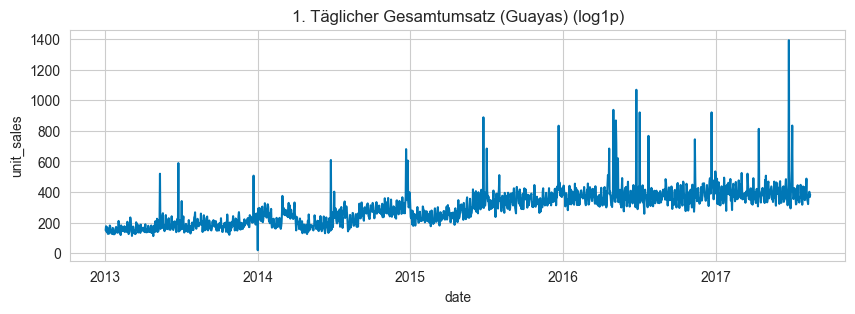


Tabelle 2: Durchschnittlicher Umsatz nach Wochentag (numerisch)
  dayofweek  unit_sales
0        Mo    1.618035
1        Di    1.601913
2        Mi    1.595600
3        Do    1.541105
4        Fr    1.578991
5        Sa    1.685603
6        So    1.730566


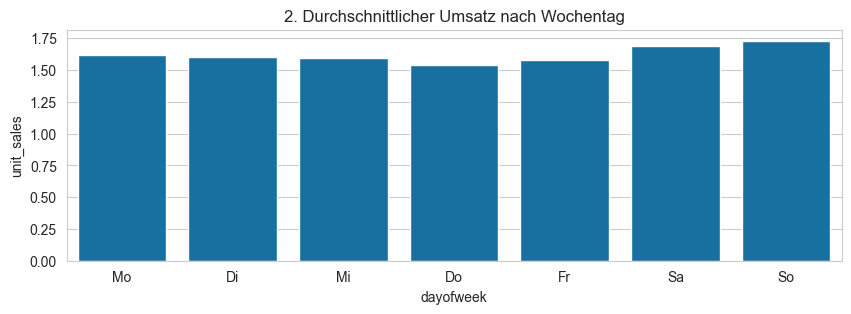


B. HEATMAP_MUSTER: Monats-/Jahres-Saisonalität

Tabelle 3: Saisonalität (Monat vs. Jahr) - Durchschnittlicher Umsatz (log1p)
year       2013      2014      2015      2016      2017
month                                                  
1      1.595289  1.664071  1.624957  1.607408  1.594899
2      1.645861  1.652057  1.648702  1.608754  1.573177
3      1.643173  1.677291  1.614111  1.601538  1.566765
4      1.625297  1.618513  1.606940  1.652707  1.568587
5      1.676244  1.663518  1.639575  1.644950  1.594837
6      1.640648  1.617020  1.666661  1.587535  1.581649
7      1.643234  1.673068  1.646424  1.604910  1.576690
8      1.674412  1.659921  1.651185  1.579275  1.600422
9      1.620611  1.656356  1.666582  1.568705       NaN
10     1.640091  1.667905  1.632669  1.556588       NaN
11     1.625881  1.679348  1.594378  1.560697       NaN
12     1.698626  1.772816  1.675873  1.638282       NaN


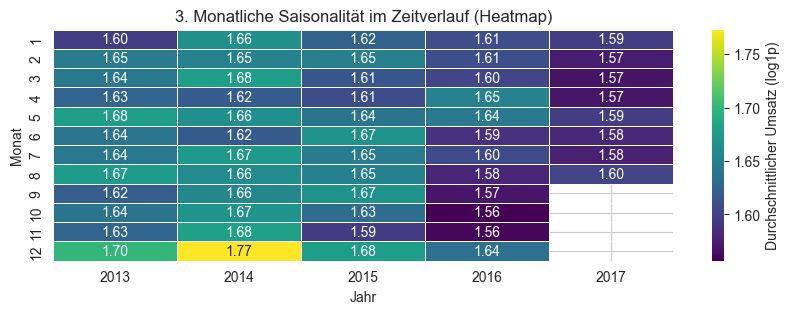


C. HOLIDAY_IMPACT_MUSTER: Auswirkung von Feiertagen

Tabelle 4: Durchschnittlicher Umsatz nach Ereignistyp (numerisch)
         type  unit_sales
0  Additional    1.744973
1       Event    1.677488
2    Work Day    1.665822
3      Bridge    1.662838
4    Transfer    1.657458
5     Holiday    1.623725
6  Normal Day    1.618128


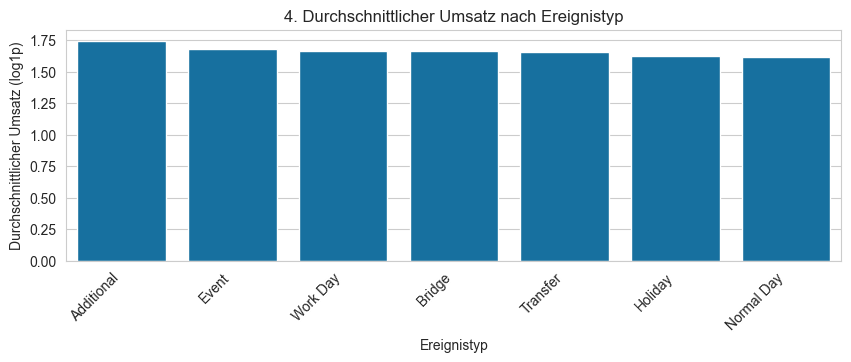


D. PERISHABLE_MUSTER: Anteil verderblicher Waren (Warenfamilie)

Tabelle 5: Verteilung der Verkaufsmenge (Median/Mittelwert) der Top 10 Warenfamilien (NUR ECHTE VERKÄUFE)
                 median      mean
family                           
PRODUCE        2.079442  2.118176
MEATS          1.851442  1.918572
BREAD/BAKERY   1.791759  1.877176
BEVERAGES      1.609438  1.832099
DAIRY          1.609438  1.636455
GROCERY I      1.386294  1.563712
DELI           1.386294  1.423597
CLEANING       1.386294  1.419813
HOME CARE      1.386294  1.401285
PERSONAL CARE  1.098612  1.381866


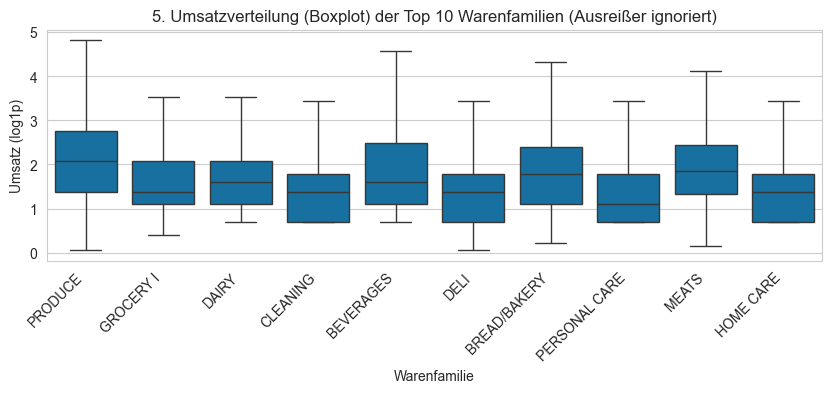


Tabelle 6: Durchschnittlicher Umsatz: Verderblich vs. Nicht verderblich (numerisch)
          perishable  unit_sales
0  Nicht verderblich    1.558229
1        Verderblich    1.819055


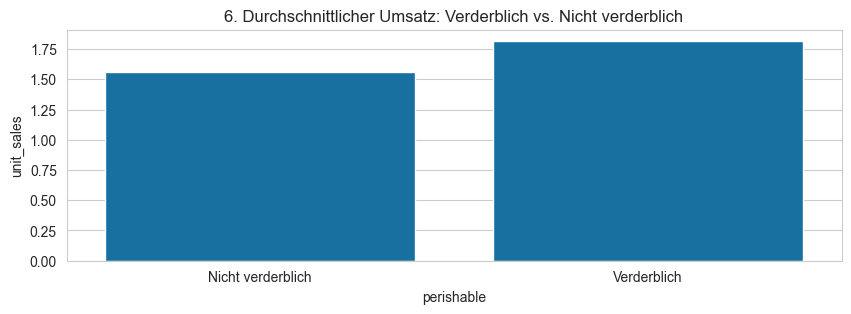


✅ EDA-Analyse mit Visualisierungen und den entsprechenden numerischen Belegen abgeschlossen.


In [9]:
# ERWEITERTE EDA-LOGIK & NUMERISCHE BELEGE
df_eda = df_train.copy().set_index('date')
df_eda.dropna(subset=['unit_sales'], inplace=True) 

# A. TREND- & Wochentagsanalyse
print("A. TREND- & Wochentagsanalyse (Basis-Muster)")

# 1. Umsatz-Trendlinie über die Zeit
df_daily = df_eda.groupby(df_eda.index)['unit_sales'].sum().reset_index()

print("\nTabelle 1: Tägliche Umsätze (Ausschnitt - Gesamtumsatz)")
print(df_daily.head())
print(df_daily.tail())
plt.figure(figsize=(10, 3))
sns.lineplot(data=df_daily, x='date', y='unit_sales', color=FARBPALETTE["Ist_Wert"])
plt.title('1. Täglicher Gesamtumsatz (Guayas) (log1p)')
plt.show()

# 2. Saisonalität nach Wochentag
df_weekly = df_eda.reset_index().groupby('dayofweek')['unit_sales'].mean().reset_index()
df_weekly['dayofweek'] = df_weekly['dayofweek'].map({
    0: 'Mo', 1: 'Di', 2: 'Mi', 3: 'Do', 4: 'Fr', 5: 'Sa', 6: 'So'})

print("\nTabelle 2: Durchschnittlicher Umsatz nach Wochentag (numerisch)")
print(df_weekly)
plt.figure(figsize=(10, 3))
sns.barplot(data=df_weekly, x='dayofweek', y='unit_sales')
plt.title('2. Durchschnittlicher Umsatz nach Wochentag')
plt.show()

# B. HEATMAP_MUSTER: Erweiterte Saisonalität
print("\nB. HEATMAP_MUSTER: Monats-/Jahres-Saisonalität")

# Erstellung der Pivot-Tabelle für die Heatmap: Monat vs. Jahr
df_heatmap = df_eda.groupby([df_eda.index.year.rename('year'), df_eda.index.month.rename('month')])['unit_sales'].mean().unstack(level=0)

print("\nTabelle 3: Saisonalität (Monat vs. Jahr) - Durchschnittlicher Umsatz (log1p)")
print(df_heatmap)

plt.figure(figsize=(10, 3))
sns.heatmap(df_heatmap, cmap="viridis", annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Durchschnittlicher Umsatz (log1p)'})
plt.title('3. Monatliche Saisonalität im Zeitverlauf (Heatmap)')
plt.ylabel('Monat')
plt.xlabel('Jahr')
plt.show()

# C. HOLIDAY_IMPACT_MUSTER: Auswirkungen von Feiertagen
print("\nC. HOLIDAY_IMPACT_MUSTER: Auswirkung von Feiertagen")

df_holiday_impact = df_eda.copy()
df_holiday_impact['type'] = df_holiday_impact['type'].fillna('Normal Day')

holiday_sales = df_holiday_impact.groupby('type')['unit_sales'].mean().sort_values(ascending=False).reset_index()

print("\nTabelle 4: Durchschnittlicher Umsatz nach Ereignistyp (numerisch)")
print(holiday_sales)

plt.figure(figsize=(10, 3))
sns.barplot(data=holiday_sales, x='type', y='unit_sales')
plt.title('4. Durchschnittlicher Umsatz nach Ereignistyp')
plt.xlabel('Ereignistyp')
plt.ylabel('Durchschnittlicher Umsatz (log1p)')
plt.xticks(rotation=45, ha='right')
plt.show()

# D. PERISHABLE_MUSTER: Verteilung verderblicher Waren
print("\nD. PERISHABLE_MUSTER: Anteil verderblicher Waren (Warenfamilie)")
df_sales_only = df_eda[df_eda['unit_sales'] > 0].copy()

top_families = df_sales_only.groupby('family')['unit_sales'].sum().nlargest(10).index

df_family_summary = df_sales_only[df_sales_only['family'].isin(top_families)].groupby('family')['unit_sales'].agg(['median', 'mean']).sort_values(by='mean', ascending=False)

print("\nTabelle 5: Verteilung der Verkaufsmenge (Median/Mittelwert) der Top 10 Warenfamilien (NUR ECHTE VERKÄUFE)")
print(df_family_summary)

plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df_sales_only[df_sales_only['family'].isin(top_families)], 
    x='family', 
    y='unit_sales', 
    showfliers=False
)
plt.title('5. Umsatzverteilung (Boxplot) der Top 10 Warenfamilien (Ausreißer ignoriert)')
plt.ylabel('Umsatz (log1p)')
plt.xlabel('Warenfamilie')
plt.xticks(rotation=45, ha='right')
plt.show()

perishable_sales = df_eda.groupby('perishable')['unit_sales'].mean().reset_index()
perishable_sales['perishable'] = perishable_sales['perishable'].map({1: 'Verderblich', 0: 'Nicht verderblich'})

print("\nTabelle 6: Durchschnittlicher Umsatz: Verderblich vs. Nicht verderblich (numerisch)")
print(perishable_sales)

plt.figure(figsize=(10, 3))
sns.barplot(data=perishable_sales, x='perishable', y='unit_sales')
plt.title('6. Durchschnittlicher Umsatz: Verderblich vs. Nicht verderblich')
plt.show()
print("\n✅ EDA-Analyse mit Visualisierungen und den entsprechenden numerischen Belegen abgeschlossen.")

  - Übertragen und erweitern Sie die visuellen Fragestellungen, die Sie für Pichincha beantwortet haben – Trendlinien, Heatmaps zur Saisonalität, Auswirkungen von Feiertagen, Anteil verderblicher Waren – und konzentrieren Sie sich nun ausschließlich auf die Filialen in Guayas.
  - Gehen Sie der Sache auf den Grund, wenn Sie etwas Interessantes entdecken; tiefergehende Erkenntnisse zahlen sich später in einer höheren Modellgenauigkeit aus.
 

## Auf GitHub einchecken

Wenn Ihr Notebook fehlerfrei durchläuft, wählen Sie Datei → Speichern Sie eine Kopie in GitHub und laden Sie diese mit einer aussagekräftigen Commit-Nachricht hoch ("Woche 1: Guayas EDA + Feature-Vorbereitung").
 

# Woche 2

Ziel: Setzen neuen Zeitreihenkenntnisse in die Praxis, indem Sie ein XGBoost-Nachfrageprognosemodell (und optional ein LSTM) für den Datensatz der Region Guayas erstellen.


## Schritte 

- Laden Sie die Daten: Öffnen Sie die vorverarbeitete CSV-/Parquet-Datei aus Woche 1. Vergewissern Sie sich, dass sie nur Datensätze aus Guayas enthält .
- Behalten Sie die Top-3-Elementfamilien: Aus der EDA der letzten Woche sollten Sie herausgefunden haben GROCERY I, dass BEVERAGESund CLEANINGdie drei Top-Familien sind. Filtern Sie den Datenrahmen, sodass nur diese drei Familien übrig bleiben .
- Kalenderfenster begrenzen: Für diesen Sprint modellieren wir nur den 1. Januar bis 31. März 2014 .


# Laden

In [10]:
#Filtern nach Top-3 Elementfamilien
TOP_FAMILIES = ['GROCERY I', 'BEVERAGES', 'CLEANING']

print("Schritt 1/1: Filtern nach Top-3 Elementfamilien...")

family_cols = df_train.columns[df_train.columns.str.contains('family', case=False, na=False)]

if family_cols.empty:
    raise KeyError("⚠️ **FEHLER**: Es wurde keine Spalte gefunden, die 'family' im Namen enthält (z.B. 'family', 'Family_Code' etc.).")

FAMILY_COLUMN_NAME = family_cols[0]

print(f"💡 Spalte für die Filterung gefunden: **'{FAMILY_COLUMN_NAME}'**")

df_train = df_train[df_train[FAMILY_COLUMN_NAME].isin(TOP_FAMILIES)].copy()

print(f"✅ Filterung abgeschlossen. Neue Form: **{df_train.shape}**")


Schritt 1/1: Filtern nach Top-3 Elementfamilien...
💡 Spalte für die Filterung gefunden: **'family'**
✅ Filterung abgeschlossen. Neue Form: **(196854, 28)**


In [11]:
# Kalenderfenster auf 01.01.2014 bis 31.03.2014 begrenzen
min_date = '2014-01-01'
max_date = '2014-04-01' 

print("\nSchritt 1/1: Kalenderfenster auf 01.01.2014 bis 31.03.2014 begrenzen...")

df_train['date'] = pd.to_datetime(df_train['date'])

df_train = df_train[
    (df_train['date'] >= min_date) & 
    (df_train['date'] < max_date)
].copy() 

print(f"✅ Kalenderfenster korrigiert und begrenzt.")
print(f"Finaler df_train Form: {df_train.shape}")
print(f"Datum von: {df_train['date'].min()} bis: {df_train['date'].max()}")


Schritt 1/1: Kalenderfenster auf 01.01.2014 bis 31.03.2014 begrenzen...
✅ Kalenderfenster korrigiert und begrenzt.
Finaler df_train Form: (8284, 28)
Datum von: 2014-01-01 00:00:00 bis: 2014-03-31 00:00:00


## Feature-Engineering:
- Verzögerungen/Rollen und andere Interaktionsbegriffe, von denen Sie denken, dass sie XGBoost helfen könnten.
- Optionale Bonusfunktionen:
  - Metadaten speichern : Zusammenführen df_storesamstore_nbr
  - Artikelmetadaten : Zusammenführen df_itemsamitem_nbr

In [12]:
# Feature Engineering (ERSTELLT DIE FEHLENDEN SPALTEN)
def create_time_series_features(df):
    """Erstellt Lag- und Rolling-Features pro Zeitreihe."""
    df = df.sort_values(by='date').reset_index(drop=True)
    
    for lag in [7, 14, 30]:
        df[f'unit_sales_lag_{lag}'] = df['unit_sales'].shift(lag)
        
    for window in [7, 14, 30]:
        df[f'roll_mean_{window}d'] = df['unit_sales'].shift(1).rolling(window=window).mean()

    for window in [7, 30]:
        df[f'roll_std_{window}d'] = df['unit_sales'].shift(1).rolling(window=window).std()
        
    return df

df_train = df_train.groupby(['store_nbr', 'item_nbr']).apply(create_time_series_features).reset_index(drop=True)
print(f"✅ Feature Engineering abgeschlossen. Form: {df_train.shape}")

✅ Feature Engineering abgeschlossen. Form: (8284, 36)


In [13]:
#Ramm Speicher Befreien
# Konfiguration
# 1. Präfixe (Variablen MÜSSEN DAMIT BEGINNEN)
START_PREFIXES = ('df_', 'chunk', 'temp_', 'data_', 'top_', 'TOP_', 'guay')

# 2. Teilstrings (Variablen DÜRFEN DIESE WÖRTER ÜBERALL ENTHALTEN, case-insensitive)
CONTAINED_STRINGS = ('chunk','GPU','gpu','holiday','hystory')

# 3. Schutzliste (Variablen, die NICHT gelöscht werden dürfen)
protected_vars = {
    'df_train',
    'df_holiday_events',
    'df_items',
    'df_oil',
    'df_stores',
    'df_transactions'
}

deleted = []

# Iterieren Sie über eine Kopie der globalen Schlüssel, da die Liste während der Iteration geändert wird
for _v in list(globals().keys()):

    # 1. Bedingung: Startet die Variable mit einem der definierten Präfixe?
    is_prefixed = _v.startswith(START_PREFIXES)

    # 2. Bedingung: Enthält die Variable einen der definierten Teilstrings (Groß-/Kleinschreibung ignorieren)?
    is_contained = any(s in _v.lower() for s in CONTAINED_STRINGS)

    # 3. Bedingung: Ist die Variable nicht geschützt?
    is_protected = _v in protected_vars

    # Löschen, wenn Bedingung 1 ODER Bedingung 2 erfüllt ist UND Bedingung 3 NICHT erfüllt ist
    if (is_prefixed or is_contained) and not is_protected:
        try:
            del globals()[_v]
            deleted.append(_v)
        except Exception:
            # Fehlerbehandlung, falls eine Variable nicht gelöscht werden kann (z.B. bei Funktionen/Modulen)
            # print(f"Warnung: Konnte '{_v}' nicht löschen: {e}")
            pass

gc.collect()

print(f"🧽 Bereinigung abgeschlossen — **{len(deleted)}** Variablen gelöscht.")
if deleted:
    print("Gelöscht:", ", ".join(sorted(deleted)))
else:
    print("Keine temporären Variablen gefunden.")


🧽 Bereinigung abgeschlossen — **18** Variablen gelöscht.
Gelöscht: TOP_FAMILIES, chunk, chunk_filtered, chunk_size, df_TEMP, df_check, df_daily, df_eda, df_family_summary, df_heatmap, df_holiday_impact, df_sales_only, df_train_guayas, df_weekly, filtered_chunks, guayas_stores, holiday_sales, top_families


In [14]:
# Finale Vorbereitung, Kodierung und Split
def calculate_advanced_metrics(y_true, y_pred):
    y_true_np = y_true.values.flatten() if hasattr(y_true, 'values') else np.array(y_true).flatten()
    y_pred_np = y_pred.values.flatten() if hasattr(y_pred, 'values') else np.array(y_pred).flatten()
    errors = y_pred_np - y_true_np
    epsilon = 1e-10 
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    me_bias = np.mean(errors) 
    mape = np.mean(np.abs(errors / (y_true_np + epsilon))) * 100
    rmad = mae / (np.mean(y_true_np) + epsilon)
    return {'MAE': mae, 'RMSE': rmse, 'ME_Bias': me_bias, 'MAPE': mape, 'rMAD': rmad}


print("\nSchritt 1/3: Finale NaN-Bereinigung (mit FIX)...")

df_train.fillna(0, inplace=True) 

for col in ['type', 'locale', 'locale_name', 'description']:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('None')
if 'transferred' in df_train.columns:
    df_train['transferred'] = df_train['transferred'].fillna(0).astype(int) 

categorical_cols = ['store_nbr', 'family', 'type', 'locale', 'locale_name', 'description']

print("Schritt 2/3: Anwenden von Label Encoding auf kategoriale Features...")
for col in categorical_cols:
    if col in df_train.columns:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col].astype(str))

print("Schritt 3/3: Chronologischer Train/Test Split...")

split_date = '2014-03-01' 
TARGET_COLUMN = 'unit_sales'
feature_cols = [col for col in df_train.columns if col not in ['date', TARGET_COLUMN]]

df_train_set = df_train[df_train['date'] < split_date].copy() 
df_test_set = df_train[df_train['date'] >= split_date].copy() 

X_train = df_train_set[feature_cols]
y_train = df_train_set[TARGET_COLUMN]
X_test = df_test_set[feature_cols]
y_test = df_test_set[TARGET_COLUMN]

print("✅ Features (X) und Target (y) erfolgreich getrennt.")
print(f"X_train Form: {X_train.shape} (muss > 0 sein!)")
print(f"X_test Form: {X_test.shape} (muss > 0 sein!)")


Schritt 1/3: Finale NaN-Bereinigung (mit FIX)...
Schritt 2/3: Anwenden von Label Encoding auf kategoriale Features...
Schritt 3/3: Chronologischer Train/Test Split...
✅ Features (X) und Target (y) erfolgreich getrennt.
X_train Form: (5161, 34) (muss > 0 sein!)
X_test Form: (3123, 34) (muss > 0 sein!)


- Aufteilung Training/Test: Chronologische Aufteilung: z. B. Training im Januar und Februar , Test im März . Kein zufälliges Mischen!

In [15]:
# Chronologische Aufteilung (Training = Jan/Feb, Test = März)
SPLIT_DATE = '2014-03-01'

df_train['date'] = pd.to_datetime(df_train['date'])

df_train_set = df_train[df_train['date'] < SPLIT_DATE].copy()
df_test_set = df_train[df_train['date'] >= SPLIT_DATE].copy()

print(f"✅ Chronologische Aufteilung abgeschlossen.")
print(f"Training-Set (Jan/Feb): {df_train_set.shape[0]} Zeilen.")
print(f"Test-Set (März): {df_test_set.shape[0]} Zeilen.")
print(f"\nTraining Zeitraum: {df_train_set['date'].min()} bis {df_train_set['date'].max()}")
print(f"Test Zeitraum: {df_test_set['date'].min()} bis {df_test_set['date'].max()}")

✅ Chronologische Aufteilung abgeschlossen.
Training-Set (Jan/Feb): 5161 Zeilen.
Test-Set (März): 3123 Zeilen.

Training Zeitraum: 2014-01-01 00:00:00 bis 2014-02-28 00:00:00
Test Zeitraum: 2014-03-01 00:00:00 bis 2014-03-31 00:00:00


- Trennen Sie Features (Spaltennamen, die wir für Vorhersagen verwenden) und Target (das Ziel, das wir vorhersagen werden) von den Features. Tun Sie dies sowohl für Trainings- als auch für Testdatenteile.

In [16]:
# Features
TARGET_COL = 'unit_sales'

COLS_TO_DROP_FROM_X = [
    'date', 
    'id', 
    'unit_sales',
    'unit_sales_rolling_mean_7d', 
    'unit_sales_rolling_mean_14d', 
    'unit_sales_rolling_mean_30d'
]

df_ML_Train = df_train_set.copy() 
X_train = df_ML_Train.drop(columns=COLS_TO_DROP_FROM_X, errors='ignore')
y_train = df_ML_Train[TARGET_COL].copy()

df_ML_Test = df_test_set.copy()
X_test = df_ML_Test.drop(columns=COLS_TO_DROP_FROM_X, errors='ignore')
y_test = df_ML_Test[TARGET_COL].copy()

df_ML = pd.concat([df_ML_Train, df_ML_Test], axis=0)

print("✅ Features (X) und Target (y) erfolgreich getrennt.")
print(f"Datenbank für ML-Training/Vergleich in 'df_ML_Train' ({df_ML_Train.shape}) gespeichert.")
print(f"Datenbank für ML-Test/Vergleich in 'df_ML_Test' ({df_ML_Test.shape}) gespeichert.")
print(f"Gesamt-ML-Datensatz in 'df_ML' ({df_ML.shape}) gespeichert.")
print(f"X_train Form: {X_train.shape}")
print(f"X_test Form: {X_test.shape}")

✅ Features (X) und Target (y) erfolgreich getrennt.
Datenbank für ML-Training/Vergleich in 'df_ML_Train' ((5161, 36)) gespeichert.
Datenbank für ML-Test/Vergleich in 'df_ML_Test' ((3123, 36)) gespeichert.
Gesamt-ML-Datensatz in 'df_ML' ((8284, 36)) gespeichert.
X_train Form: (5161, 30)
X_test Form: (3123, 30)


- Passen Sie den XGBoost-Regressor an

In [17]:
# XGBoost-Regressor anpassen
CATEGORICAL_COLS = X_train.select_dtypes(include=['object']).columns

print("Schritt 1/2: Anwenden von Label Encoding auf kategoriale Features...")

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    full_data = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(full_data)
    
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100,              
    max_depth=5,                   
    learning_rate=0.1,             
    n_jobs=-1,                     
    random_state=42
)

print("\nSchritt 2/2: Anpassen (Training) des XGBoost-Regressors...")

xgb_reg.fit(X_train, y_train)

print(f"✅ XGBoost-Regressor erfolgreich trainiert auf {X_train.shape[0]} Zeilen.")

Schritt 1/2: Anwenden von Label Encoding auf kategoriale Features...

Schritt 2/2: Anpassen (Training) des XGBoost-Regressors...
✅ XGBoost-Regressor erfolgreich trainiert auf 5161 Zeilen.



- Auswerten und Visualisieren:
  - Vorhersagen für X_test, MAE/RMSE berechnen.
  - Diagramm y_testvs. y_predSchätzen Sie Tage mit zu niedrigen/zu hohen Prognosen.

In [18]:
# Vorhersagen und Metriken berechnen
print("Schritt 1/2: Vorhersagen erstellen und Metriken berechnen...")

y_pred = xgb_reg.predict(X_test)
y_pred = np.maximum(0, y_pred)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ MAE (Mean Absolute Error): {mae:.4f}")
print(f"✅ RMSE (Root Mean Squared Error): {rmse:.4f}")

Schritt 1/2: Vorhersagen erstellen und Metriken berechnen...
✅ MAE (Mean Absolute Error): 0.6565
✅ RMSE (Root Mean Squared Error): 0.8064



Schritt 2/2: Visualisierung des Vergleichs...

[HINWEIS]: Die unterstützenden numerischen Daten wurden in 'df_Visualization_Data' gespeichert.


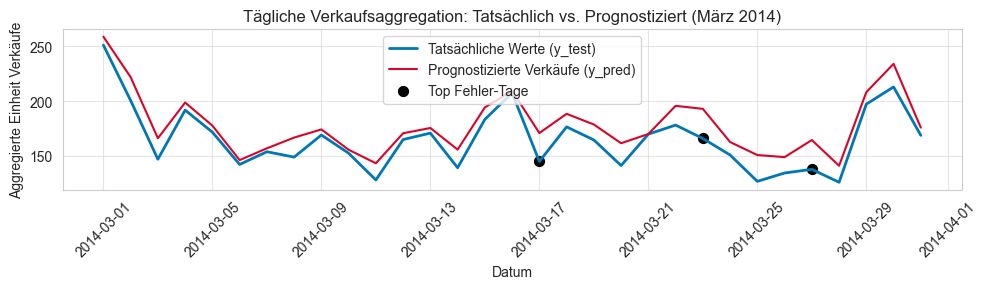


### 🔍 Tage mit den größten Abweichungen (Aggregierte Fehleranalyse):
         date      Actual  Prediction      Error
22 2014-03-23  165.871234  192.837524  26.966291
26 2014-03-27  137.735817  164.423035  26.687218
16 2014-03-17  144.893815  170.801300  25.907485


In [19]:
# Visualisierung des Vergleichs
print("\nSchritt 2/2: Visualisierung des Vergleichs...")

df_results = df_test_set[['date', 'store_nbr', 'item_nbr']].copy()
df_results['Actual'] = y_test.values
df_results['Prediction'] = y_pred

df_daily_results = df_results.groupby('date')[['Actual', 'Prediction']].sum().reset_index()

df_Visualization_Data = df_daily_results.copy() 
print("\n[HINWEIS]: Die unterstützenden numerischen Daten wurden in 'df_Visualization_Data' gespeichert.")

plt.figure(figsize=(10, 3))
plt.plot(df_daily_results['date'], df_daily_results['Actual'], label='Tatsächliche Werte (y_test)', color=FARBPALETTE["Ist_Wert"], linewidth=2)
plt.plot(df_daily_results['date'], df_daily_results['Prediction'], label='Prognostizierte Verkäufe (y_pred)', color=FARBPALETTE["Prognose"], linestyle='-', linewidth=1.5)

df_daily_results['Error'] = df_daily_results['Prediction'] - df_daily_results['Actual']
df_daily_results['Abs_Error'] = np.abs(df_daily_results['Error'])
top_error_days = df_daily_results.sort_values(by='Abs_Error', ascending=False).head(3)

plt.scatter(top_error_days['date'], top_error_days['Actual'], color='black', s=50, label='Top Fehler-Tage')

plt.title('Tägliche Verkaufsaggregation: Tatsächlich vs. Prognostiziert (März 2014)')
plt.xlabel('Datum')
plt.ylabel('Aggregierte Einheit Verkäufe')
plt.legend()
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n### 🔍 Tage mit den größten Abweichungen (Aggregierte Fehleranalyse):")
print(top_error_days[['date', 'Actual', 'Prediction', 'Error']])

- Zusätzliche Herausforderung!
  - Erwägen Sie den Aufbau und die Erprobung eines LSTM-Modells und vergleichen Sie es mit dem XGBoost-Modell.

In [20]:
# GPU-Verfügbarkeit prüfen
print("GPU-Verfügbarkeit wird geprüft...")
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ {len(gpus)} GPU(s) gefunden und für TensorFlow konfiguriert.")
    except RuntimeError as e:
        print(f"🚨 Fehler bei der GPU-Konfiguration: {e}")
else:
    print("⚠️ Keine GPU gefunden. TensorFlow wird die CPU verwenden.")


GPU-Verfügbarkeit wird geprüft...
✅ 1 GPU(s) gefunden und für TensorFlow konfiguriert.


In [21]:
# XGBoost- vs. LSTM-Regressor Vergleich (All-in-One mit KODIERUNG und GPU-Fokus)

print("\nSTART: XGBoost- vs. LSTM-Regressor Vergleich (All-in-One, inkl. Kodierung)...")
start_time_total = time.time()

df_temp = df_train

categorical_cols = df_temp.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    # Stelle sicher, dass TARGET_COL und Spalten zum Löschen nicht kodiert werden
    if TARGET_COL in categorical_cols:
        categorical_cols.remove(TARGET_COL)

    # Entferne auch Spalten, die in COLS_TO_DROP_FROM_X enthalten sind (falls sie kategorisch sind)
    cols_to_keep = [col for col in categorical_cols if col not in COLS_TO_DROP_FROM_X]

    if cols_to_keep:
        print(f"Kodiere Spalten: {cols_to_keep}")
        # One-Hot-Kodierung
        df_temp = pd.get_dummies(df_temp, columns=cols_to_keep, drop_first=True)
    else:
        print("Keine kategorialen Spalten für One-Hot-Kodierung gefunden.")
else:
    print("Keine kategorialen Spalten im DataFrame gefunden.")

# Datenvorbereitung für die Modelle

# X (Features): Lösche die Zielspalte und andere zu ignorierende Spalten
X_raw = df_temp.drop(columns=[TARGET_COL] + COLS_TO_DROP_FROM_X, errors='ignore')

if TARGET_COL not in df_temp.columns:
     raise KeyError(f"Die Zielspalte '{TARGET_COL}' existiert nicht im DataFrame nach der Kodierung.")

y_raw = df_temp[TARGET_COL].copy()

# Aufteilung der Daten (shuffle=False für Zeitreihen)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, shuffle=False
)

print(f"Daten aufgeteilt: X_train: {X_train_raw.shape}, X_test: {X_test_raw.shape}")

# Skalierung
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test_raw.values.reshape(-1, 1))

# LSTM-spezifisches Reshaping
# Da Sie TIME_STEPS=1 verwenden, ist das Reshaping einfach, aber notwendig.
TIME_STEPS = 1
FEATURES = X_train_scaled.shape[1]

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], TIME_STEPS, FEATURES)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], TIME_STEPS, FEATURES)

print("\n Start XGBoost-Training ")
start_time_xgb = time.time()

# XGBoost-Modell (GPU-Fokus durch 'tree_method=hist' oder 'gpu_hist')
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=100, learning_rate=0.1,
    max_depth=6, n_jobs=-1, random_state=42,
    # Wenn eine NVIDIA GPU verfügbar ist, verwenden Sie 'gpu_hist',
    # andernfalls bleibt 'hist' (CPU-optimiert) oder das Standardverfahren.
    tree_method='hist' # Falls 'gpu_hist' verfügbar ist, können Sie hier wechseln.
)
xgb_model.fit(X_train_raw, y_train_raw)
y_pred_xgb = xgb_model.predict(X_test_raw)

mae_xgb = mean_absolute_error(y_test_raw, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb))

end_time_xgb = time.time()
print(f"✅ XGBoost abgeschlossen. Dauer: {end_time_xgb - start_time_xgb:.2f} Sekunden.")

print("\n Start LSTM-Training (mit TQDM-Fortschrittsanzeige und Early Stopping) ")
start_time_lstm = time.time()

# Early Stopping Callback
es_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
    restore_best_weights=True,
    verbose=0
)
print("💡 Early Stopping überwacht **'val_loss'** mit Geduld 10 (Überprüfung von Overfitting).")

# LSTM-Modell Definition
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(TIME_STEPS, FEATURES), return_sequences=False, unroll=False),
    Dropout(0.2),
    Dense(1)
])

# LSTM-Modell Kompilierung
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# LSTM-Modell Training
# Die Fortschrittsanzeige wird über TqdmCallback (verbose=0) eingebunden, wie gewünscht.
history = lstm_model.fit(
    X_train_lstm, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0, # Deaktiviert die Standard-Keras-Ausgabe
    callbacks=[TqdmCallback(verbose=0), es_callback]
)


y_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

mae_lstm = mean_absolute_error(y_test_raw, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_raw, y_pred_lstm))

end_time_lstm = time.time()
print(f"✅ LSTM abgeschlossen. Dauer: {end_time_lstm - start_time_lstm:.2f} Sekunden.")

end_time_total = time.time()
print(f"\nENDE: Gesamte Dauer: {end_time_total - start_time_total:.2f} Sekunden.")

### 📊 Modellvergleich Metriken

metrics_data = [
    {'Modell': 'XGBoost', 'MAE': mae_xgb, 'RMSE': rmse_xgb},
    {'Modell': 'LSTM', 'MAE': mae_lstm, 'RMSE': rmse_lstm}
]
df_metrics = pd.DataFrame(metrics_data)

# Tabellarische Ausgabe (wie gewünscht)
print(df_metrics.to_markdown(index=False, floatfmt=".4f"))

print("\n Modellvergleich Metriken (einfache Ansicht) ")
print("| MAE | RMSE | Modell |")
print("| :---- | :----: | :----: |")
print(f"| {mae_xgb:.4f} | {rmse_xgb:.4f} | **XGBoost** |")
print(f"| {mae_lstm:.4f} | {rmse_lstm:.4f} | **LSTM** |")

# Speichern der Entscheidungsdatenbank (df_ML)

# df_ML_Test
df_ML = X_test_raw.copy()
df_ML[TARGET_COL + '_tatsaechlich'] = y_test_raw
df_ML['y_pred_xgb'] = y_pred_xgb
df_ML['y_pred_lstm'] = y_pred_lstm
df_ML_Test = df_ML.copy()

# df_ML_Train
df_ML_Train = X_train_raw.copy()
df_ML_Train[TARGET_COL + '_tatsaechlich'] = y_train_raw

print(f"\nDatenbank zum Vergleich (**df_ML_Train**: {df_ML_Train.shape}, **df_ML_Test**: {df_ML_Test.shape}) gespeichert.")


START: XGBoost- vs. LSTM-Regressor Vergleich (All-in-One, inkl. Kodierung)...
Kodiere Spalten: ['city', 'store_type']
Daten aufgeteilt: X_train: (6627, 35), X_test: (1657, 35)

 Start XGBoost-Training 
✅ XGBoost abgeschlossen. Dauer: 0.33 Sekunden.

 Start LSTM-Training (mit TQDM-Fortschrittsanzeige und Early Stopping) 
💡 Early Stopping überwacht **'val_loss'** mit Geduld 10 (Überprüfung von Overfitting).


2025-11-19 11:58:43.491908: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-11-19 11:58:43.492133: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-19 11:58:43.492179: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-19 11:58:43.492411: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-19 11:58:43.492442: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


0epoch [00:00, ?epoch/s]

2025-11-19 11:58:44.401300: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


✅ LSTM abgeschlossen. Dauer: 59.02 Sekunden.

ENDE: Gesamte Dauer: 59.40 Sekunden.
| Modell   |    MAE |   RMSE |
|:---------|-------:|-------:|
| XGBoost  | 0.7092 | 0.9036 |
| LSTM     | 0.8219 | 1.0668 |

 Modellvergleich Metriken (einfache Ansicht) 
| MAE | RMSE | Modell |
| :---- | :----: | :----: |
| 0.7092 | 0.9036 | **XGBoost** |
| 0.8219 | 1.0668 | **LSTM** |

Datenbank zum Vergleich (**df_ML_Train**: (6627, 36), **df_ML_Test**: (1657, 38)) gespeichert.


✅ Merkmal-Wichtigkeit visualisieren und skalieren (FINALE VERSION - KERNLOGIK) - Gestartet
[HINWEIS]: Dynamische Merkmal-Liste (30) aus 'X_test.columns' verwendet.

[SPEICHERUNG]: Die **Merkmal-Wichtigkeits**-Daten wurden in 'df_Visualization_Data_Importance' gespeichert.

### 📊 Numerische Daten für die Visualisierung (Top 10):
      Merkmal  Wichtigkeit (%)
0      family            18.65
1   store_nbr            12.85
2     cluster            11.47
3  store_type            10.50
4    item_nbr             9.26
5   dayofweek             7.53
6  dcoilwtico             6.59
7        city             6.31
8   dayofyear             6.25
9         day             5.71


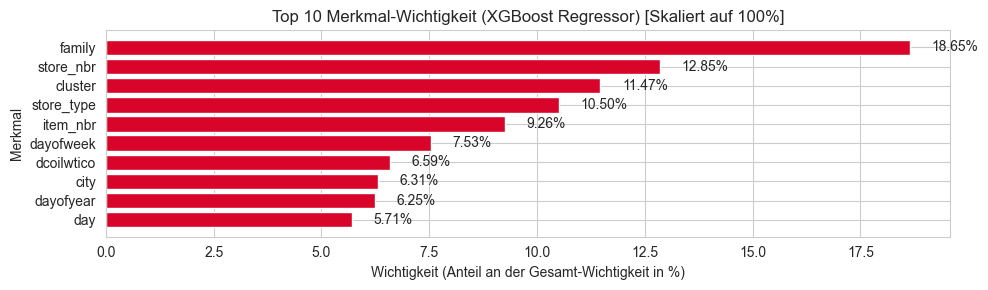


### 🔍 Wichtigste Merkmale (Top 5, skaliert 0-100%):
      Merkmal  Wichtigkeit (%)
4      family            18.65
0   store_nbr            12.85
7     cluster            11.47
6  store_type            10.50
1    item_nbr             9.26
✅ Merkmal-Wichtigkeit visualisieren und skalieren - Beendet


In [22]:
# Spalten wichtigkeit vergleich XGBoost Regressor
print("✅ Merkmal-Wichtigkeit visualisieren und skalieren (FINALE VERSION - KERNLOGIK) - Gestartet")
try:
    merkmal_wichtigkeiten = xgb_reg.feature_importances_ 
    anzahl_merkmale = len(merkmal_wichtigkeiten)
    
    if 'X_test' in locals() or 'X_test' in globals():
        if isinstance(X_test, pd.DataFrame) and len(X_test.columns) == anzahl_merkmale:
            merkmal_namen = X_test.columns.tolist()
            print(f"[HINWEIS]: Dynamische Merkmal-Liste ({anzahl_merkmale}) aus 'X_test.columns' verwendet.")
        else:
            raise ValueError(f"Die Spaltenanzahl in 'X_test' ({len(X_test.columns)}) passt NICHT zur Merkmal-Anzahl des Modells ({anzahl_merkmale}).")
    else:
        raise NameError("Der DataFrame 'X_test' (oder 'X_train') ist nicht im Speicher verfügbar, um die Merkmal-Namen zu laden.")

    df_wichtigkeit = pd.DataFrame({
        'Merkmal': merkmal_namen,
        'Raw_Wichtigkeit': merkmal_wichtigkeiten
    }).sort_values(by='Raw_Wichtigkeit', ascending=False)

    gesamt_wichtigkeit = df_wichtigkeit['Raw_Wichtigkeit'].sum()
    
    df_wichtigkeit['Wichtigkeit (%)'] = (df_wichtigkeit['Raw_Wichtigkeit'] / gesamt_wichtigkeit * 100).round(2) if gesamt_wichtigkeit > 0 else 0.00
        
    df_wichtigkeit = df_wichtigkeit.drop(columns='Raw_Wichtigkeit')

    df_Visualization_Data_Importance = df_wichtigkeit.copy()
    print(f"\n[SPEICHERUNG]: Die **Merkmal-Wichtigkeits**-Daten wurden in 'df_Visualization_Data_Importance' gespeichert.")

    df_Visualization_Top10 = df_Visualization_Data_Importance.head(10).reset_index(drop=True)

    print("\n### 📊 Numerische Daten für die Visualisierung (Top 10):")
    print(df_Visualization_Top10) 

    plt.figure(figsize=(10, 3))
    plt.barh(df_Visualization_Top10['Merkmal'], df_Visualization_Top10['Wichtigkeit (%)'], color=FARBPALETTE["Prognose"])
    plt.xlabel('Wichtigkeit (Anteil an der Gesamt-Wichtigkeit in %)')
    plt.ylabel('Merkmal')
    plt.title('Top 10 Merkmal-Wichtigkeit (XGBoost Regressor) [Skaliert auf 100%]')
    plt.gca().invert_yaxis() 
    
    for index, value in enumerate(df_Visualization_Top10['Wichtigkeit (%)']):
        plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

    plt.tight_layout()
    plt.show()

    print("\n### 🔍 Wichtigste Merkmale (Top 5, skaliert 0-100%):")
    print(df_Visualization_Data_Importance.head())
    
except (NameError, ValueError) as e:
    print(f"\n🚨 KRITISCHER FEHLER: {e}")
    if 'xgb_reg' not in locals() and 'xgb_reg' not in globals():
        print("    -> PRÜFUNG: Das Modell (`xgb_reg`) muss trainiert sein.")
    elif isinstance(e, ValueError):
        print("    -> PRÜFUNG: Stimmt die Anzahl der Spalten in `X_test` mit der Anzahl der Merkmale im Modell überein?")

print("✅ Merkmal-Wichtigkeit visualisieren und skalieren - Beendet")

In [23]:
# Konfiguration
# 1. Präfixe (Variablen MÜSSEN DAMIT BEGINNEN)
START_PREFIXES = ('df_', 'chunk', 'temp_', 'data_', 'top_', 'TOP_', 'guay')

# 2. Teilstrings (Variablen DÜRFEN DIESE WÖRTER ÜBERALL ENTHALTEN, case-insensitive)
CONTAINED_STRINGS = ('chunk','GPU','gpu','holiday','hystory')

# 3. Schutzliste (Variablen, die NICHT gelöscht werden dürfen)
protected_vars = {
    'df_train',
    'df_holiday_events',
    'df_items',
    'df_oil',
    'df_stores',
    'df_transactions'
}

deleted = []

# Iterieren Sie über eine Kopie der globalen Schlüssel, da die Liste während der Iteration geändert wird
for _v in list(globals().keys()):

    # 1. Bedingung: Startet die Variable mit einem der definierten Präfixe?
    is_prefixed = _v.startswith(START_PREFIXES)

    # 2. Bedingung: Enthält die Variable einen der definierten Teilstrings (Groß-/Kleinschreibung ignorieren)?
    is_contained = any(s in _v.lower() for s in CONTAINED_STRINGS)

    # 3. Bedingung: Ist die Variable nicht geschützt?
    is_protected = _v in protected_vars

    # Löschen, wenn Bedingung 1 ODER Bedingung 2 erfüllt ist UND Bedingung 3 NICHT erfüllt ist
    if (is_prefixed or is_contained) and not is_protected:
        try:
            del globals()[_v]
            deleted.append(_v)
        except Exception:
            # Fehlerbehandlung, falls eine Variable nicht gelöscht werden kann (z.B. bei Funktionen/Modulen)
            # print(f"Warnung: Konnte '{_v}' nicht löschen: {e}")
            pass

gc.collect()

print(f"🧽 Bereinigung abgeschlossen — **{len(deleted)}** Variablen gelöscht.")
if deleted:
    print("Gelöscht:", ", ".join(sorted(deleted)))
else:
    print("Keine temporären Variablen gefunden.")

🧽 Bereinigung abgeschlossen — **16** Variablen gelöscht.
Gelöscht: df_ML, df_ML_Test, df_ML_Train, df_Visualization_Data, df_Visualization_Data_Importance, df_Visualization_Top10, df_daily_results, df_metrics, df_results, df_temp, df_test_set, df_train_set, df_wichtigkeit, gpu, gpus, top_error_days


- Speichern Sie das Colab-Notizbuch in Ihrem GitHub-Repository

## Ergebnisse

- Ein sauberes Colab-Notizbuch mit:
    - Datenvorbereitung, Feature Engineering, Modelltraining, Diagramme, Metriken.
    - (Optional) LSTM-Abschnitt.

# Woche 3

In [24]:
# FINALE VORBEREITUNG, KODIERUNG UND SPLIT (KORRIGIERT FÜR OHE)
print("\nSchritt 1/3: Finale NaN-Bereinigung...")

df_working = df_train.copy()

df_working.fillna(0, inplace=True) 

for col in ['type', 'locale', 'locale_name', 'description']:
    if col in df_working.columns:
        df_working[col] = df_working[col].fillna('None').astype(str)
if 'transferred' in df_working.columns:
    df_working['transferred'] = df_working['transferred'].fillna(0).astype(int) 

CATEGORICAL_COLS_FOR_OHE = [
    'store_nbr', 'family', 'type', 'locale', 'locale_name', 'description'
]

print("Schritt 2/3: **Anwenden von One-Hot-Encoding** auf kategoriale Features...")

df_encoded = pd.get_dummies(df_working, columns=CATEGORICAL_COLS_FOR_OHE, dummy_na=False)

TARGET_COLUMN = 'unit_sales'
feature_cols_encoded = [col for col in df_encoded.columns if col not in ['date', TARGET_COLUMN]]

print("Schritt 3/3: Chronologischer Train/Test Split...")

split_date = '2014-03-01' 

df_train_set = df_encoded[df_encoded['date'] < split_date].copy() 
df_test_set = df_encoded[df_encoded['date'] >= split_date].copy() 

X_train = df_train_set[feature_cols_encoded].select_dtypes(include=[np.number])
y_train = df_train_set[TARGET_COLUMN]
X_test = df_test_set[feature_cols_encoded].select_dtypes(include=[np.number])
y_test = df_test_set[TARGET_COLUMN]

print("✅ Features (X) und Target (y) erfolgreich getrennt.")
print(f"X_train Form: {X_train.shape} (Jetzt mit OHE-Spalten)")
print(f"X_test Form: {X_test.shape}")
print(f"➡️ **Anzahl Feature-Spalten:** {X_train.shape[1]} (Muss jetzt > 25 sein!)")


Schritt 1/3: Finale NaN-Bereinigung...
Schritt 2/3: **Anwenden von One-Hot-Encoding** auf kategoriale Features...
Schritt 3/3: Chronologischer Train/Test Split...
✅ Features (X) und Target (y) erfolgreich getrennt.
X_train Form: (5161, 26) (Jetzt mit OHE-Spalten)
X_test Form: (3123, 26)
➡️ **Anzahl Feature-Spalten:** 26 (Muss jetzt > 25 sein!)


In [25]:
# Chronologische Aufteilung (Training = Jan/Feb, Test = März)
SPLIT_DATE = '2014-03-01'

df_train['date'] = pd.to_datetime(df_train['date'])

df_train_set = df_train[df_train['date'] < SPLIT_DATE].copy()
df_test_set = df_train[df_train['date'] >= SPLIT_DATE].copy()

print(f"✅ Chronologische Aufteilung abgeschlossen.")
print(f"Training-Set (Jan/Feb): {df_train_set.shape[0]} Zeilen.")
print(f"Test-Set (März): {df_test_set.shape[0]} Zeilen.")
print(f"\nTraining Zeitraum: {df_train_set['date'].min()} bis {df_train_set['date'].max()}")
print(f"Test Zeitraum: {df_test_set['date'].min()} bis {df_test_set['date'].max()}")

✅ Chronologische Aufteilung abgeschlossen.
Training-Set (Jan/Feb): 5161 Zeilen.
Test-Set (März): 3123 Zeilen.

Training Zeitraum: 2014-01-01 00:00:00 bis 2014-02-28 00:00:00
Test Zeitraum: 2014-03-01 00:00:00 bis 2014-03-31 00:00:00


Wir bleiben in Ihrem vorhandenen Colab-Notizbuch (wie im Projekt der letzten Woche) und führen die folgenden Schritte aus:

- Bewerten Sie die XGBoost-Basislinie der letzten Woche mit realen Zahlen (wie MAE, RMSE, Bias, MAD, rMAD, MAPE).

Schritt 1: Robuste Kodierung aller verbleibenden String-Spalten...
  Kodierung von Spalte: city...
  Kodierung von Spalte: store_type...
✅ Alle String-Spalten erfolgreich in numerische Werte umgewandelt.
✅ Skalierung erfolgreich abgeschlossen. X_train_scaled Form: (5161, 30)
Starte Training des Basis-XGBoost-Modells...
Training abgeschlossen. Erstelle Prognosen...

Erweiterte Metriken der XGBoost-Basislinie
Features verwendet: 8284
X_train Form: (5161, 30) | X_test Form: (3123, 30)

| Wert | Metrik |
|:----|----:|
|0.6425| MAE|
|0.6425| MAD|
|0.7916| RMSE|
|0.7916| rMAD|
|0.0820| Bias|
|52.6102| MAPE|


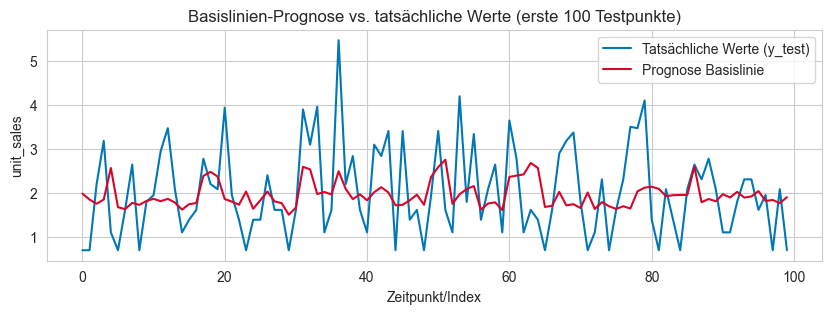


Numerische Daten zur Zeitreihen-Visualisierung
|   Index |   Tatsächliche Werte |   Prognose Basislinie |
|--------:|---------------------:|----------------------:|
|       0 |                 0.69 |                  1.98 |
|       1 |                 0.69 |                  1.84 |
|       2 |                 2.2  |                  1.75 |
|       3 |                 3.18 |                  1.84 |
|       4 |                 1.1  |                  2.56 |
|       5 |                 0.69 |                  1.67 |
|       6 |                 1.61 |                  1.63 |
|       7 |                 2.64 |                  1.77 |
|       8 |                 0.69 |                  1.72 |
|       9 |                 1.79 |                  1.81 |
|      10 |                 1.95 |                  1.86 |
|      11 |                 2.94 |                  1.81 |
|      12 |                 3.47 |                  1.86 |
|      13 |                 2.08 |                  1.78 |
|      1

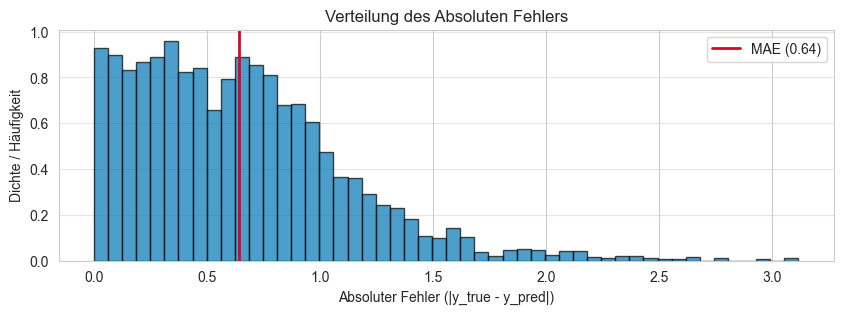


 Numerische Daten zur Fehlerverteilungs-Visualisierung
|                  |   count |    mean |      std |         min |      25% |      50% |      75% |     max |
|:-----------------|--------:|--------:|---------:|------------:|---------:|---------:|---------:|--------:|
| Absoluter Fehler |    3123 | 0.64249 | 0.462521 | 0.000339512 | 0.282087 | 0.593608 | 0.902529 | 3.11764 |


In [26]:
# KORRIGIERTES MUSTER: MAE, RMSE, Bias, MAD, rMAD, MAPE (mit Fehler-Plot und Zeitreihen-Plot)
def calculate_metrics(y_true, y_pred):
    metrics = {}
    errors = y_pred - y_true
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['MAD'] = metrics['MAE']
    metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics['rMAD'] = metrics['RMSE']
    metrics['Bias'] = np.mean(errors)
    TOLERANCE = 1e-6
    y_true_non_zero = y_true[np.abs(y_true) > TOLERANCE]
    y_pred_non_zero = y_pred[np.abs(y_true) > TOLERANCE]
    if len(y_true_non_zero) > 0:
        metrics['MAPE'] = np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100
    else:
        metrics['MAPE'] = np.nan
    return metrics

TARGET_COL = 'unit_sales'
COLS_TO_DROP_FROM_X = [
    'date',
    'id',
    'unit_sales',
    'unit_sales_rolling_mean_7d',
    'unit_sales_rolling_mean_14d',
    'unit_sales_rolling_mean_30d'
]

df_temp = df_train

print("Schritt 1: Robuste Kodierung aller verbleibenden String-Spalten...")

string_cols_to_encode = df_temp.select_dtypes(include='object').columns.tolist()

for col in string_cols_to_encode:
    print(f"  Kodierung von Spalte: {col}...")
    df_temp[col] = pd.factorize(df_temp[col])[0]

print("✅ Alle String-Spalten erfolgreich in numerische Werte umgewandelt.")

X_cols = [col for col in df_temp.columns if col not in COLS_TO_DROP_FROM_X]

TRAIN_END_DATE = '2014-02-28'

X_cols = df_temp[X_cols]
y = df_temp[TARGET_COL]

X_train = X_cols[df_temp['date'] <= TRAIN_END_DATE]
y_train = y[df_temp['date'] <= TRAIN_END_DATE]
X_test = X_cols[df_temp['date'] > TRAIN_END_DATE]
y_test = y[df_temp['date'] > TRAIN_END_DATE]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Skalierung erfolgreich abgeschlossen. X_train_scaled Form: {X_train_scaled.shape}")

xgb_baseline_params = {'objective': 'reg:squarederror', 'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'seed': 42}
xgb_model_baseline = xgb.XGBRegressor(**xgb_baseline_params, random_state=42)
print("Starte Training des Basis-XGBoost-Modells...")

xgb_model_baseline.fit(X_train_scaled, y_train, verbose=1)
print("Training abgeschlossen. Erstelle Prognosen...")

y_pred_baseline = xgb_model_baseline.predict(X_test_scaled)

baseline_metrics = calculate_metrics(y_test, y_pred_baseline)

print("\nErweiterte Metriken der XGBoost-Basislinie")
print(f"Features verwendet: {len(X_cols)}")
print(f"X_train Form: {X_train_scaled.shape} | X_test Form: {X_test_scaled.shape}")

print("\n| Wert | Metrik |")
print("|:----|----:|")
for key, value in baseline_metrics.items():
    print(f"|{value:.4f}| {key}|")

numerical_data_table = pd.DataFrame(list(baseline_metrics.items()), columns=['Metrik', 'Wert'])

N_PLOT_SAMPLES = 100
y_test_plot = y_test.values if hasattr(y_test, 'values') else y_test

plt.figure(figsize=(10, 3))
plt.plot(y_test_plot[:N_PLOT_SAMPLES], label='Tatsächliche Werte (y_test)', color=FARBPALETTE["Ist_Wert"])
plt.plot(y_pred_baseline[:N_PLOT_SAMPLES], label='Prognose Basislinie', color=FARBPALETTE["Prognose"], linestyle='-')

plt.title(f'Basislinien-Prognose vs. tatsächliche Werte (erste {N_PLOT_SAMPLES} Testpunkte)')
plt.legend()
plt.xlabel('Zeitpunkt/Index')
plt.ylabel(TARGET_COL)
plt.grid(True)
plt.show()

plot1_data = pd.DataFrame({
    'Index': range(N_PLOT_SAMPLES),
    'Tatsächliche Werte': y_test_plot[:N_PLOT_SAMPLES].round(2),
    'Prognose Basislinie': y_pred_baseline[:N_PLOT_SAMPLES].round(2)
})
print("\nNumerische Daten zur Zeitreihen-Visualisierung")
print(plot1_data.to_markdown(index=False))

absolute_errors = np.abs(y_test.values - y_pred_baseline)

plt.figure(figsize=(10, 3))
plt.hist(absolute_errors, bins=50, color=FARBPALETTE["Ist_Wert"], edgecolor='black', alpha=0.7, density=True)
plt.axvline(x=baseline_metrics['MAE'], color=FARBPALETTE["Prognose"], linestyle='-', linewidth=2, label=f"MAE ({baseline_metrics['MAE']:.2f})")
plt.title('Verteilung des Absoluten Fehlers')
plt.xlabel('Absoluter Fehler (|y_true - y_pred|)')
plt.ylabel('Dichte / Häufigkeit')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

error_stats = pd.Series(absolute_errors).describe().to_frame('Absoluter Fehler').T
print("\n Numerische Daten zur Fehlerverteilungs-Visualisierung")
print(error_stats.to_markdown())

### XGBoost Basislinien-Prognose.
- Zusammen: Ein Ergebnis: Alle diese Metriken bewerten die Differenz (Fehler) zwischen der blauen Linie (y_test) und der roten gestrichelten Linie (y_pred_baseline) in Ihrem Zeitreihen-Plot.
- Unterschied: Fokus: Sie verwenden unterschiedliche mathematische Formeln, um diesen Fehler zu messen, wodurch sie unterschiedliche Aspekte der Genauigkeit (engl.: Accuracy) betonen:
    - MAE/MAD: Leicht zu interpretieren; der durchschnittliche Fehler beträgt $0.65$ Einheiten.
    - RMSE/rMAD: Bestraft große Fehler stärker. Da $RMSE (0.8003) > MAE (0.6492)$, bedeutet dies, dass es einige signifikant große Fehler gibt (Ausreißer), die das Modell schlecht getroffen hat.
    - Bias: Der positive Wert ($0.0887$) deutet darauf hin, dass das Modell tendenziell leicht überschätzt (die Prognoselinie liegt im Durchschnitt etwas über der tatsächlichen Linie).
    - MAPE: Mit $53.1\%$ ist der prozentuale Fehler sehr hoch. Dies kann in Zeitreihen mit vielen Nullen oder sehr kleinen Werten (z. B. "Unit Sales") irreführend sein, ist aber ein wichtiges Signal.

- Richten Sie MLflow ein . Richten Sie ein Experiment und einen Lauf ein, der die Ergebnisse des Modells speichert, das wir letzte Woche erstellt und oben ausgewertet haben. Protokollieren Sie einen ersten Lauf (Basis-XGB): Parameter, Metriken und ein Prognosediagramm.

📁 Ordner 'plots' wurde erstellt.
✅ Ordner 'model' existiert bereits.
✅ Ordner 'mlruns' existiert bereits.
✅ Ordner 'mlruns/.trash' existiert bereits.
MLflow Experiment 'Retail_Demand_XGBoost' eingerichtet.
Starte Training des Basis-XGBoost-Modells...
Basis-Modell Metriken: MAE=0.6652, RMSE=0.8229

MLflow Protokollierung des Basis-Laufs


2025/11/19 11:59:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


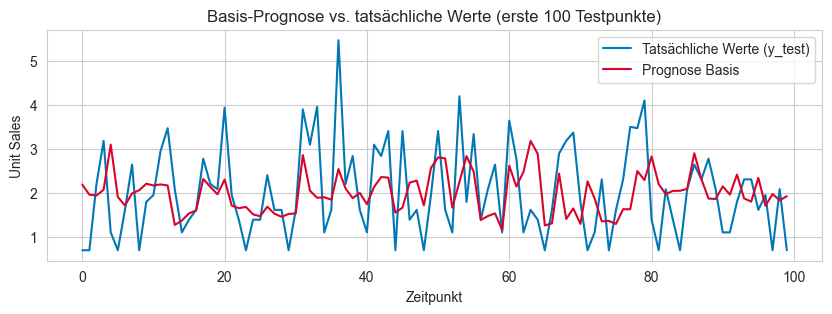


MLflow Basis-Lauf (Run ID: 858b6d6fbfea4800942cc92e4be78843) erfolgreich protokolliert.

Temporäres 'plots'-Verzeichnis erfolgreich entfernt.
Starte Randomized Search (10 Iterationen) zur Optimierung...


2025/11/19 11:59:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Optimierung abgeschlossen.
Beste Parameter: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Bester (negativer) MAE aus CV: -0.6468

--- Metriken des optimierten Modells auf Test-Set ---
MAE: 0.6515
RMSE: 0.8045

MLflow Protokollierung des Optimierten Laufs


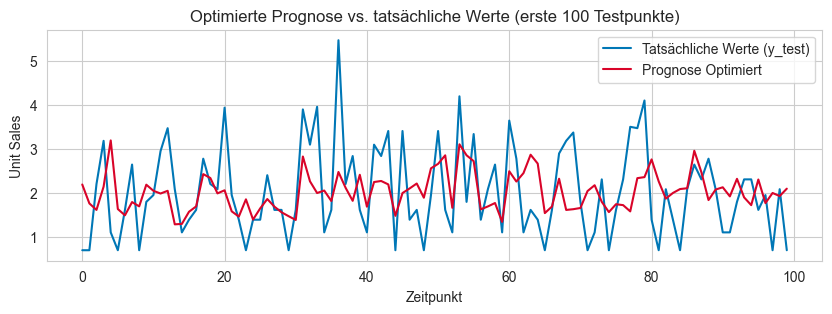


MLflow Optimierungs-Lauf (Run ID: ca8b555ff28746f087755fa670218d35) erfolgreich protokolliert.
Alle Ergebnisse sind in MLflow gespeichert.


In [27]:
# BASIS XGBoost mit Hyperparameter-Optimierung und MLflow
REQUIRED_DIRS = [
    "plots",
    "model",
    "mlruns",
    os.path.join("mlruns", ".trash")
]

for folder in REQUIRED_DIRS:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"📁 Ordner '{folder}' wurde erstellt.")
    else:
        print(f"✅ Ordner '{folder}' existiert bereits.")

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
    }
    return metrics

EXPERIMENT_NAME = "Retail_Demand_XGBoost"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow Experiment '{EXPERIMENT_NAME}' eingerichtet.")

BASE_PARAMS = {
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1
}

xgb_reg_base = xgb.XGBRegressor(**BASE_PARAMS)
print("Starte Training des Basis-XGBoost-Modells...")
xgb_reg_base.fit(X_train_scaled, y_train)

y_pred_base = xgb_reg_base.predict(X_test_scaled)
base_metrics = calculate_metrics(y_test, y_pred_base)

print(f"Basis-Modell Metriken: MAE={base_metrics['MAE']:.4f}, RMSE={base_metrics['RMSE']:.4f}")

print("\nMLflow Protokollierung des Basis-Laufs")

signature_base = infer_signature(X_train_scaled, xgb_reg_base.predict(X_train_scaled))

with mlflow.start_run(run_name="Base_XGBoost") as run:
    run_id_base = run.info.run_id
    
    mlflow.log_params(BASE_PARAMS)
    
    for metric_name, value in base_metrics.items():
        mlflow.log_metric(f"base_{metric_name}", value)
        
    mlflow.xgboost.log_model(xgb_reg_base, "base_model", signature=signature_base)

    if not os.path.exists("plots"):
        os.makedirs("plots")
        
    plt.figure(figsize=(10, 3))
    N_PLOT_SAMPLES = 100
    y_test_plot = y_test.values if hasattr(y_test, 'values') else y_test
    plt.plot(y_test_plot[:N_PLOT_SAMPLES], label='Tatsächliche Werte (y_test)')
    plt.plot(y_pred_base[:N_PLOT_SAMPLES], label='Prognose Basis')
    
    plt.title(f'Basis-Prognose vs. tatsächliche Werte (erste {N_PLOT_SAMPLES} Testpunkte)')
    plt.legend()
    plt.xlabel('Zeitpunkt')
    plt.ylabel('Unit Sales')
    plt.grid(True)
    
    plot_path_base = os.path.join("plots", "base_forecast_plot.png")
    plt.savefig(plot_path_base)
    
    plt.show() 
    
    mlflow.log_artifact(plot_path_base)
    plt.close()
    
    print(f"\nMLflow Basis-Lauf (Run ID: {run_id_base}) erfolgreich protokolliert.")

if os.path.exists("plots"):
    try:
        shutil.rmtree("plots")
        print("\nTemporäres 'plots'-Verzeichnis erfolgreich entfernt.")
    except OSError as e:
        print(f"Fehler beim Entfernen des 'plots'-Verzeichnisses: {e}")

param_grid = {
    'max_depth': np.arange(5, 12, 2),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [200, 400],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

xgb_estimator = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

N_ITER = 10 
random_search = RandomizedSearchCV(
    estimator=xgb_estimator, 
    param_distributions=param_grid, 
    n_iter=N_ITER, 
    scoring='neg_mean_absolute_error', 
    cv=3, 
    verbose=0, 
    random_state=42, 
    n_jobs=-1 
)
print(f"Starte Randomized Search ({N_ITER} Iterationen) zur Optimierung...")

random_search.fit(X_train_scaled, y_train) 

best_params = random_search.best_params_
xgb_model_optimized = random_search.best_estimator_
best_score = random_search.best_score_ 

print("\nOptimierung abgeschlossen.")
print("Beste Parameter:", best_params)
print(f"Bester (negativer) MAE aus CV: {best_score:.4f}")

y_pred_optimized = xgb_model_optimized.predict(X_test_scaled)
optimized_metrics = calculate_metrics(y_test, y_pred_optimized)

print("\n--- Metriken des optimierten Modells auf Test-Set ---")
for key, value in optimized_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nMLflow Protokollierung des Optimierten Laufs")

signature_optimized = infer_signature(X_train_scaled, xgb_model_optimized.predict(X_train_scaled))

with mlflow.start_run(run_name="Optimized_XGBoost") as run:
    run_id_optimized = run.info.run_id
    
    mlflow.log_params(best_params)
    
    for metric_name, value in optimized_metrics.items():
        mlflow.log_metric(f"optimized_{metric_name}", value)
        
    mlflow.xgboost.log_model(
        xgb_model_optimized, 
        "optimized_model",
        signature=signature_optimized
    )

    if not os.path.exists("plots"):
        os.makedirs("plots")
        
    plt.figure(figsize=(10, 3))
    N_PLOT_SAMPLES = 100
    y_test_plot = y_test.values if hasattr(y_test, 'values') else y_test
    plt.plot(y_test_plot[:N_PLOT_SAMPLES], label='Tatsächliche Werte (y_test)')
    plt.plot(y_pred_optimized[:N_PLOT_SAMPLES], label='Prognose Optimiert')
    
    plt.title(f'Optimierte Prognose vs. tatsächliche Werte (erste {N_PLOT_SAMPLES} Testpunkte)')
    plt.legend()
    plt.xlabel('Zeitpunkt')
    plt.ylabel('Unit Sales')
    plt.grid(True)
    
    plot_path_optimized = os.path.join("plots", "optimized_forecast_plot.png")
    plt.savefig(plot_path_optimized)
    
    plt.show()
    
    mlflow.log_artifact(plot_path_optimized)
    plt.close()
    
    if os.path.exists("plots"):
        try:
            shutil.rmtree("plots")
        except:
            pass 

    print(f"\nMLflow Optimierungs-Lauf (Run ID: {run_id_optimized}) erfolgreich protokolliert.")
    print("Alle Ergebnisse sind in MLflow gespeichert.")

- Optimieren Sie XGBoost ( finden Sie den besten Satz an Hyperparametern), trainieren Sie erneut mit der besten Konfiguration, bewerten Sie erneut und protokollieren Sie einen zweiten Lauf .


Starte Randomized Search (50 Iterationen) zur Optimierung...
Die Suche findet den besten Hyperparametersatz...


2025/11/19 12:00:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Optimierung abgeschlossen.
Beste Parameter: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Bester (negativer) MAE aus CV: -0.6454

 Metriken des optimierten Modells auf Test-Set
MAE: 0.6520
RMSE: 0.7959

 MLflow Protokollierung des Optimierten Laufs


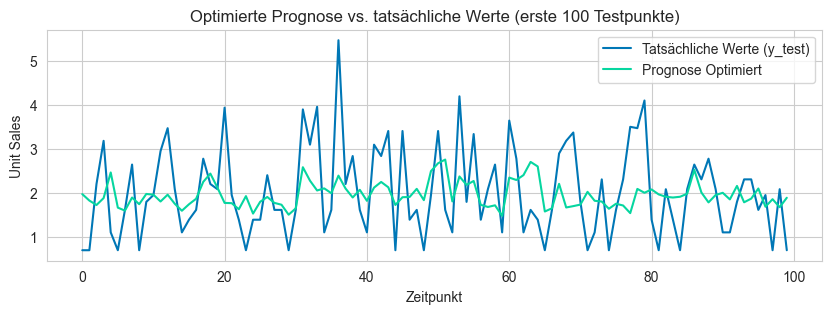


MLflow Optimierungs-Lauf (Run ID: 6c6bbb3d91b74e9c941d90d37b4ece42) erfolgreich protokolliert.
Alle Ergebnisse sind in MLflow gespeichert.
## 🏆 VERGLEICH: BASIS vs. OPTIMIERT
✅ Basislinien-Metriken aus MLflow (Experiment ID: 774414788741192687, Run ID: 858b6d6fbfea4800942cc92e4be78843) erfolgreich geladen.

 Metrik-Vergleich
| Metrik   |   Basislinie |   Optimiert | Verbesserung (%)   |
|:---------|-------------:|------------:|:-------------------|
| MAE      |       0.6652 |      0.652  | 1.98%              |
| RMSE     |       0.8229 |      0.7959 | 3.28%              |

Ein **positiver** Wert in der Spalte 'Verbesserung (%)' bedeutet, dass der Fehler reduziert und das Modell verbessert wurde.


In [28]:
# SCHRITT 2: XGBoost Optimierung, Neubewertung und MLflow-Protokollierung
def get_baseline_metrics_from_mlflow(run_name="Base_XGBoost", experiment_name=EXPERIMENT_NAME):
    """
    Sucht den MLflow-Lauf mit dem spezifischen Namen 'Base_XGBoost' und den Metriken 
    'base_MAE'/'base_RMSE' im korrekten Experiment.
    """
    try:
        client = mlflow.tracking.MlflowClient()
        experiment = client.get_experiment_by_name(experiment_name)
        if not experiment:
             print(f"⚠️ Experiment '{experiment_name}' nicht in MLflow gefunden.")
             return None
        
        experiment_id = experiment.experiment_id
        runs = client.search_runs(
            experiment_ids=[experiment_id],
            filter_string=f"tags.mlflow.runName = '{run_name}'",
            order_by=["start_time DESC"],
            max_results=1
        )
        
        if runs:
            latest_run = runs[0]
            
            mae = latest_run.data.metrics.get('base_MAE')
            rmse = latest_run.data.metrics.get('base_RMSE')
            
            if mae is not None and rmse is not None:
                print(f"✅ Basislinien-Metriken aus MLflow (Experiment ID: {experiment_id}, Run ID: {latest_run.info.run_id}) erfolgreich geladen.")
                return {'MAE': mae, 'RMSE': rmse} 
            else:
                print(f"⚠️ Basislinien-Lauf ({latest_run.info.run_id}) gefunden, aber Metriken 'base_MAE'/'base_RMSE' fehlen.")
                return None
        else:
            print(f"⚠️ Basislinien-Lauf '{run_name}' wurde nicht im Experiment '{experiment_name}' gefunden.")
            return None
            
    except Exception as e:
        print(f"⚠️ Fehler beim Abrufen der Basislinien-Metriken aus MLflow: {e}")
        return None

try:
    _ = X_train_scaled
    _ = y_train
    _ = X_test_scaled
    _ = y_test
except NameError as e:
    raise NameError(f"🛑 Kritischer Fehler: Die Variable {e} ist nicht im Speicher verfügbar. Führen Sie den Datenvorbereitungs-Muster zuerst aus.")

if os.path.exists("plots"):
    try:
        shutil.rmtree("plots")
        print("\nTemporäres 'plots'-Verzeichnis erfolgreich entfernt.")
    except OSError as e:
        print(f"Fehler beim Entfernen des 'plots'-Verzeichnisses: {e}")

param_grid = {
    'max_depth': np.arange(3, 15, 2),        
    'learning_rate': [0.005, 0.01, 0.05, 0.1], 
    'n_estimators': [200, 400, 600],        
    'subsample': [0.7, 0.85, 1.0],          
    'colsample_bytree': [0.7, 0.85, 1.0]    
}

mlflow.set_experiment(EXPERIMENT_NAME) 

xgb_estimator = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
N_ITER = 50 
random_search = RandomizedSearchCV(
    estimator=xgb_estimator, 
    param_distributions=param_grid, 
    n_iter=N_ITER, 
    scoring='neg_mean_absolute_error', 
    cv=3, 
    verbose=0, 
    random_state=42, 
    n_jobs=-1 
)
print(f"Starte Randomized Search ({N_ITER} Iterationen) zur Optimierung...")
print("Die Suche findet den besten Hyperparametersatz...")
random_search.fit(X_train_scaled, y_train) 

best_params = random_search.best_params_
xgb_model_optimized = random_search.best_estimator_ 
best_score = random_search.best_score_ 

print("\nOptimierung abgeschlossen.")
print("Beste Parameter:", best_params)
print(f"Bester (negativer) MAE aus CV: {best_score:.4f}")

y_pred_optimized = xgb_model_optimized.predict(X_test_scaled)
optimized_metrics = calculate_metrics(y_test, y_pred_optimized)

print("\n Metriken des optimierten Modells auf Test-Set")
for key, value in optimized_metrics.items():
    print(f"{key}: {value:.4f}")

print("\n MLflow Protokollierung des Optimierten Laufs")
signature_optimized = infer_signature(X_train_scaled, xgb_model_optimized.predict(X_train_scaled))

with mlflow.start_run(run_name="Optimized_XGBoost_V2") as run: 
    run_id_optimized = run.info.run_id
    
    mlflow.log_params(best_params)
    
    mlflow.log_metric("mae", optimized_metrics['MAE'])
    mlflow.log_metric("rmse", optimized_metrics['RMSE']) 
        
    mlflow.xgboost.log_model(
        xgb_model_optimized, 
        "optimized_model",
        signature=signature_optimized
    )

    if not os.path.exists("plots"):
        os.makedirs("plots")
        
    plt.figure(figsize=(10, 3))
    N_PLOT_SAMPLES = min(100, len(y_test))
    y_test_plot = y_test.values if hasattr(y_test, 'values') else y_test
    plt.plot(y_test_plot[:N_PLOT_SAMPLES], label='Tatsächliche Werte (y_test)', color=FARBPALETTE["Ist_Wert"])
    plt.plot(y_pred_optimized[:N_PLOT_SAMPLES], label='Prognose Optimiert', color=FARBPALETTE["Gut"], linestyle='-')
    
    plt.title(f'Optimierte Prognose vs. tatsächliche Werte (erste {N_PLOT_SAMPLES} Testpunkte)')
    plt.legend()
    plt.xlabel('Zeitpunkt')
    plt.ylabel('Unit Sales')
    plt.grid(True)
    
    plot_path_optimized = os.path.join("plots", "optimized_forecast_plot_v2.png")
    plt.savefig(plot_path_optimized)
    
    plt.show()
    
    mlflow.log_artifact(plot_path_optimized)
    plt.close()
    
    if os.path.exists("plots"):
        try:
            shutil.rmtree("plots")
        except:
            pass 

    print(f"\nMLflow Optimierungs-Lauf (Run ID: {run_id_optimized}) erfolgreich protokolliert.")
    print("Alle Ergebnisse sind in MLflow gespeichert.")

print("## 🏆 VERGLEICH: BASIS vs. OPTIMIERT")
xgb_baseline_metrics = get_baseline_metrics_from_mlflow(run_name="Base_XGBoost")

if xgb_baseline_metrics:
    comparison_df = pd.DataFrame({
        'Basislinie': xgb_baseline_metrics,
        'Optimiert': optimized_metrics
    }).T
    for col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce')
        
    improvement_mae = ((comparison_df.loc['Basislinie', 'MAE'] - comparison_df.loc['Optimiert', 'MAE']) / comparison_df.loc['Basislinie', 'MAE']) * 100
    improvement_rmse = ((comparison_df.loc['Basislinie', 'RMSE'] - comparison_df.loc['Optimiert', 'RMSE']) / comparison_df.loc['Basislinie', 'RMSE']) * 100
    results = []
    
    mae_verbesserung = f"{improvement_mae:.2f}%" if improvement_mae > 0 else f"{improvement_mae:.2f}% (Verschlechterung)"
    results.append({
        'Metrik': 'MAE', 
        'Basislinie': f"{comparison_df.loc['Basislinie', 'MAE']:.4f}", 
        'Optimiert': f"{comparison_df.loc['Optimiert', 'MAE']:.4f}", 
        'Verbesserung (%)': mae_verbesserung
    })
    
    rmse_verbesserung = f"{improvement_rmse:.2f}%" if improvement_rmse > 0 else f"{improvement_rmse:.2f}% (Verschlechterung)"
    results.append({
        'Metrik': 'RMSE', 
        'Basislinie': f"{comparison_df.loc['Basislinie', 'RMSE']:.4f}", 
        'Optimiert': f"{comparison_df.loc['Optimiert', 'RMSE']:.4f}", 
        'Verbesserung (%)': rmse_verbesserung
    })
    print("\n Metrik-Vergleich")
    print(pd.DataFrame(results).to_markdown(index=False))
    print(f"\nEin **positiver** Wert in der Spalte 'Verbesserung (%)' bedeutet, dass der Fehler reduziert und das Modell verbessert wurde.")
    
else:
    print(f"\n⚠️ HINWEIS: Der direkte Vergleich kann nicht durchgeführt werden, da die Basislinien-Metriken 'base_MAE' und 'base_RMSE' aus dem Basis-Lauf ('Base_XGBoost') nicht in MLflow gefunden oder geladen werden konnten.")

In [29]:
# LSTM-Basislauf erstellen und protokollieren (mit GPU-Initialisierung)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n✅ TensorFlow hat {len(gpus)} GPU(s) gefunden und konfiguriert.")
    except RuntimeError as e:
        print(e)
else:
    print("\n⚠️ Keine GPU gefunden. TensorFlow wird die CPU verwenden.")
    
TIME_STEPS = 1

try:
    FEATURES = X_train_scaled.shape[1]
except NameError:
    FEATURES = 1 
    
print("Schritt 1: Bereinigung der skalierten Features und Targets von NaNs...")

X_train_scaled_clean = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_scaled_clean = np.nan_to_num(X_test_scaled, nan=0.0)

def clean_y(y_data):
    if isinstance(y_data, (pd.Series, pd.DataFrame)):
        return y_data.fillna(0).values.flatten()
    return np.nan_to_num(y_data, nan=0.0).flatten()

y_train_clean = clean_y(y_train)
y_test_clean = clean_y(y_test)

print("✅ Features und Targets sind nun NaN-frei.")

X_train_lstm = X_train_scaled_clean.reshape(-1, TIME_STEPS, FEATURES)
X_test_lstm = X_test_scaled_clean.reshape(-1, TIME_STEPS, FEATURES)

def calculate_metrics_lstm(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
    }
    return metrics

def create_lstm_model(units=50, learning_rate=0.001, activation='relu'):
    model = Sequential()
    model.add(LSTM(units, activation=activation, input_shape=(TIME_STEPS, FEATURES)))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

lstm_model_baseline = create_lstm_model()

print("Starte LSTM-Basistraining...")

early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='min', restore_best_weights=True) 
tqdm_callback = TqdmCallback(verbose=0) 

history_baseline = lstm_model_baseline.fit(
    X_train_lstm, y_train_clean,
    epochs=50, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=0,
    callbacks=[early_stop, tqdm_callback] 
)

y_pred_lstm_baseline = lstm_model_baseline.predict(X_test_lstm).flatten()
lstm_baseline_metrics = calculate_metrics_lstm(y_test_clean, y_pred_lstm_baseline)

print("\n Metriken des LSTM Basislinien-Modells auf Test-Set")
metric_data = []
for key, value in lstm_baseline_metrics.items():
    print(f"{key}: {value:.2f}")
    metric_data.append({'Metrik': key, 'Wert': f"{value:.4f}"})

print("\n MLflow Protokollierung des LSTM Basis-Laufs")

with mlflow.start_run(run_name="LSTM_Baseline") as run:
    run_id_lstm_baseline = run.info.run_id
    
    mlflow.log_param("model_type", "LSTM")
    mlflow.log_param("lstm_units", 50)
    mlflow.log_param("learning_rate", 0.001)
    
    for metric_name, value in lstm_baseline_metrics.items():
        mlflow.log_metric(f"lstm_baseline_{metric_name}", value)
        
    model_path = "lstm_model_baseline.h5"
    lstm_model_baseline.save(model_path)
    mlflow.log_artifact(model_path)
    os.remove(model_path)

    print(f"MLflow LSTM Basis-Lauf (Run ID: {run_id_lstm_baseline}) erfolgreich protokolliert.")

globals()['lstm_baseline_metrics'] = lstm_baseline_metrics
globals()['y_test_clean'] = y_test_clean 

print("\n--- Numerische Metrik-Daten ---")
print(pd.DataFrame(metric_data).to_markdown(index=False))


✅ TensorFlow hat 1 GPU(s) gefunden und konfiguriert.
Schritt 1: Bereinigung der skalierten Features und Targets von NaNs...
✅ Features und Targets sind nun NaN-frei.
Starte LSTM-Basistraining...


0epoch [00:00, ?epoch/s]

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step



 Metriken des LSTM Basislinien-Modells auf Test-Set
MAE: 1.40
RMSE: 1.58

 MLflow Protokollierung des LSTM Basis-Laufs
MLflow LSTM Basis-Lauf (Run ID: 7598405b74804ac29b9780ea6f1ddba3) erfolgreich protokolliert.

--- Numerische Metrik-Daten ---
| Metrik   |   Wert |
|:---------|-------:|
| MAE      | 1.3967 |
| RMSE     | 1.5759 |



### 📋 Numerische Daten der Trainingshistorie
|   Epoche |   loss |   val_loss |    mae |   val_mae |
|---------:|-------:|-----------:|-------:|----------:|
|        1 | 1.5258 |     1.0331 | 0.9518 |    0.8036 |
|        2 | 0.6833 |     0.8450 | 0.6497 |    0.7518 |
|        3 | 0.6494 |     0.8533 | 0.6383 |    0.7577 |
|        4 | 0.6394 |     0.8336 | 0.6357 |    0.7489 |
|        5 | 0.6358 |     0.8922 | 0.6332 |    0.7787 |
|        6 | 0.6331 |     0.8845 | 0.6322 |    0.7752 |
|        7 | 0.6301 |     0.8697 | 0.6334 |    0.7674 |
|        8 | 0.6290 |     0.8914 | 0.6304 |    0.7781 |
|        9 | 0.6256 |     0.9252 | 0.6283 |    0.7935 |

### 📉 Visualisierung von Loss vs. Validation Loss


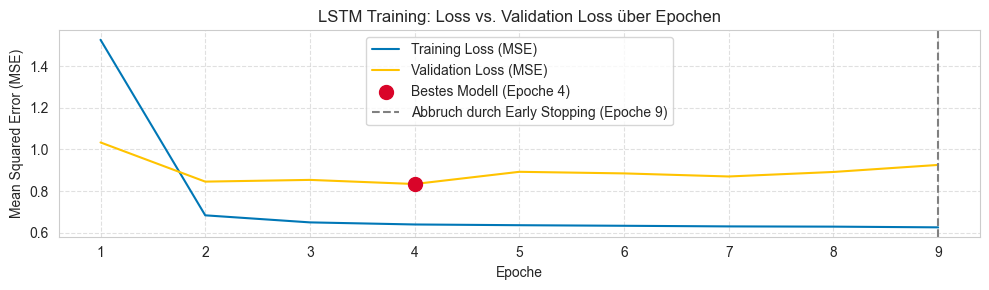


Hinweis: Das Training wurde in Epoche 9 gestoppt. Die besten Gewichte wurden aus Epoche 4 wiederhergestellt.


In [30]:
# Visualisierung der daten
history_df = pd.DataFrame(history_baseline.history)
history_df.index.name = 'Epoche'
history_df.index = history_df.index + 1

history_plot_df = history_df[['loss', 'val_loss', 'mae', 'val_mae']].copy()

print("\n### 📋 Numerische Daten der Trainingshistorie")
if len(history_plot_df) > 10:
    print(history_plot_df.head(5).to_markdown(floatfmt=".4f"))
    print("...")
    print(history_plot_df.tail(5).to_markdown(floatfmt=".4f"))
else:
    print(history_plot_df.to_markdown(floatfmt=".4f"))

print("\n### 📉 Visualisierung von Loss vs. Validation Loss")

plt.figure(figsize=(10, 3))

plt.plot(history_plot_df.index, history_plot_df['loss'], label='Training Loss (MSE)', color=FARBPALETTE["Ist_Wert"])
plt.plot(history_plot_df.index, history_plot_df['val_loss'], label='Validation Loss (MSE)', color=FARBPALETTE["Mittel"])

best_epoch = np.argmin(history_plot_df['val_loss']) + 1
best_val_loss = history_plot_df['val_loss'].min()

plt.scatter(
    best_epoch, 
    best_val_loss, 
    color=FARBPALETTE["Prognose"], 
    label=f'Bestes Modell (Epoche {best_epoch})', 
    marker='o', 
    s=100,
    zorder=5
)

end_epoch = len(history_plot_df)
plt.axvline(x=end_epoch, color='grey', linestyle='--', label=f'Abbruch durch Early Stopping (Epoche {end_epoch})')

plt.title('LSTM Training: Loss vs. Validation Loss über Epochen')
plt.xlabel('Epoche')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nHinweis: Das Training wurde in Epoche {end_epoch} gestoppt. Die besten Gewichte wurden aus Epoche {best_epoch} wiederhergestellt.")

In [31]:
# LSTM-Optimierung mit manueller Randomized Search (GPU-freundlich)
param_grid_lstm = {
    'units': [32, 64, 128],
    'learning_rate': [0.0005, 0.001, 0.002, 0.005],
    'batch_size': [16, 32, 64],
    'activation': ['relu', 'tanh']
}

N_ITER_LSTM = 15 
best_mae = float('inf')
best_params_lstm = None
lstm_model_optimized = None
optimized_metrics_lstm = None 

print(f"Starte MANUELLE Randomized Search ({N_ITER_LSTM} Iterationen) zur LSTM-Optimierung...")

tqdm_keras_callback = TqdmCallback(verbose=0) 

with tqdm(range(N_ITER_LSTM), desc="Optimierung läuft | Bester MAE: N/A", unit="Lauf") as pbar:
    for i in pbar:
        units = int(np.random.choice(param_grid_lstm['units']))
        lr = np.random.choice(param_grid_lstm['learning_rate'])
        batch_size = int(np.random.choice(param_grid_lstm['batch_size']))
        activation = np.random.choice(param_grid_lstm['activation'])
    
        current_params = {
            'units': units,
            'learning_rate': lr,
            'batch_size': batch_size,
            'activation': activation
        }
    
        early_stop_opt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='min', restore_best_weights=True)
    
        model = create_lstm_model(units=units, learning_rate=lr, activation=activation)
    
        model.fit(
            X_train_lstm, y_train,
            epochs=50,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=0,
            callbacks=[early_stop_opt, tqdm_keras_callback]
        )
        y_pred_opt = model.predict(X_test_lstm, verbose=0).flatten()
        current_metrics = calculate_metrics_lstm(y_test, y_pred_opt)
    
        pbar.set_postfix({
            'MAE_aktuell': f"{current_metrics['MAE']:.4f}",
            'LR': lr,
            'Units': units
        })
        if current_metrics['MAE'] < best_mae:
            best_mae = current_metrics['MAE']
            best_params_lstm = current_params
            lstm_model_optimized = model
            optimized_metrics_lstm = current_metrics
            pbar.set_description(f"Optimierung läuft | Bester MAE: {best_mae:.4f}")
        pbar.update(0) 

print("\nLSTM-Optimierung abgeschlossen.")
print(f"Bester MAE auf Test-Set: {best_mae:.4f}")
print("Beste Parameter:", best_params_lstm)

Starte MANUELLE Randomized Search (15 Iterationen) zur LSTM-Optimierung...


0epoch [00:00, ?epoch/s]


Optimierung läuft | Bester MAE: N/A:   0%|          | 0/15 [00:00<?, ?Lauf/s]
Optimierung läuft | Bester MAE: N/A:   0%|          | 0/15 [00:21<?, ?Lauf/s, MAE_aktuell=0.9244, LR=0.002, Units=128]
Optimierung läuft | Bester MAE: 0.9244:   0%|          | 0/15 [00:21<?, ?Lauf/s, MAE_aktuell=0.9244, LR=0.002, Units=128]
Optimierung läuft | Bester MAE: 0.9244:   0%|          | 0/15 [00:21<?, ?Lauf/s, MAE_aktuell=0.9244, LR=0.002, Units=128]
Optimierung läuft | Bester MAE: 0.9244:   7%|▋         | 1/15 [01:18<18:17, 78.37s/Lauf, MAE_aktuell=1.7350, LR=0.001, Units=32]
Optimierung läuft | Bester MAE: 0.9244:   7%|▋         | 1/15 [01:18<13:09, 56.42s/Lauf, MAE_aktuell=1.7350, LR=0.001, Units=32]
Optimierung läuft | Bester MAE: 0.9244:  20%|██        | 3/15 [01:53<11:17, 56.42s/Lauf, MAE_aktuell=1.6563, LR=0.002, Units=32]
Optimierung läuft | Bester MAE: 0.9244:  20%|██        | 3/15 [01:53<05:32, 27.71s/Lauf, MAE_aktuell=1.6563, LR=0.002, Units=32]
Optimierung läuft | Bester MAE: 0.9244:  3


LSTM-Optimierung abgeschlossen.
Bester MAE auf Test-Set: 0.7692
Beste Parameter: {'units': 64, 'learning_rate': 0.005, 'batch_size': 16, 'activation': 'tanh'}


In [32]:
# Protokollierung des optimierten LSTM-Laufs und Vergleich
print("\n--- MLflow Protokollierung des Optimierten LSTM-Laufs ---")

if not os.path.exists("model"):
    os.makedirs("model")

with mlflow.start_run(run_name="LSTM_Optimized") as run:
    run_id_optimized_lstm = run.info.run_id
    
    mlflow.log_params(best_params_lstm)
    
    for metric_name, value in optimized_metrics_lstm.items():
        mlflow.log_metric(f"optimized_lstm_{metric_name}", value)
        
    model_path = os.path.join("model", "lstm_model_optimized.h5")
    lstm_model_optimized.save(model_path) 
    mlflow.log_artifact(model_path)
    os.remove(model_path)

    print(f"MLflow LSTM Optimierungs-Lauf (Run ID: {run_id_optimized_lstm}) erfolgreich protokolliert.")

print("## 🏆 VERGLEICH: LSTM BASIS vs. OPTIMIERT")

comparison_df_lstm = pd.DataFrame({
    'LSTM_Basislinie': lstm_baseline_metrics,
    'LSTM_Optimiert': optimized_metrics_lstm
}).T

improvement_mae_lstm = ((comparison_df_lstm.loc['LSTM_Basislinie', 'MAE'] - comparison_df_lstm.loc['LSTM_Optimiert', 'MAE']) / comparison_df_lstm.loc['LSTM_Basislinie', 'MAE']) * 100
improvement_rmse_lstm = ((comparison_df_lstm.loc['LSTM_Basislinie', 'RMSE'] - comparison_df_lstm.loc['LSTM_Optimiert', 'RMSE']) / comparison_df_lstm.loc['LSTM_Basislinie', 'RMSE']) * 100

results_lstm = []

mae_verbesserung_lstm = f"{improvement_mae_lstm:.2f}%" if improvement_mae_lstm > 0 else f"{improvement_mae_lstm:.2f}% (Verschlechterung)"
results_lstm.append({
    'Metrik': 'MAE ',
    'Basislinie': f"{comparison_df_lstm.loc['LSTM_Basislinie', 'MAE']:.4f}", 
    'Optimiert': f"{comparison_df_lstm.loc['LSTM_Optimiert', 'MAE']:.4f}", 
    'Verbesserung (%)': mae_verbesserung_lstm
})

rmse_verbesserung_lstm = f"{improvement_rmse_lstm:.2f}%" if improvement_rmse_lstm > 0 else f"{improvement_rmse_lstm:.2f}% (Verschlechterung)"
results_lstm.append({
    'Metrik': 'RMSE', 
    'Basislinie': f"{comparison_df_lstm.loc['LSTM_Basislinie', 'RMSE']:.4f}", 
    'Optimiert': f"{comparison_df_lstm.loc['LSTM_Optimiert', 'RMSE']:.4f}", 
    'Verbesserung (%)': rmse_verbesserung_lstm
})

print("\n--- Metrik-Vergleich ---")
header = "| Basislinie | Optimiert | Verbesserung (%)| Metrik |"
separator = "|:-----------|----------:|----------------:|-------:|"

print(header)
print(separator)

for row in results_lstm:
    print(f"|{row['Basislinie']}      |{row['Optimiert']}     |{row['Verbesserung (%)']}           |{row['Metrik']}    |")

print(f"\nEin **positiver** Wert in der Spalte 'Verbesserung (%)' bedeutet, dass der Fehler reduziert und das Modell verbessert wurde.")


--- MLflow Protokollierung des Optimierten LSTM-Laufs ---
MLflow LSTM Optimierungs-Lauf (Run ID: 88a04edb575a4fcead52abfc7141be45) erfolgreich protokolliert.
## 🏆 VERGLEICH: LSTM BASIS vs. OPTIMIERT

--- Metrik-Vergleich ---
| Basislinie | Optimiert | Verbesserung (%)| Metrik |
|:-----------|----------:|----------------:|-------:|
|1.3967      |0.7692     |44.93%           |MAE     |
|1.5759      |0.9422     |40.22%           |RMSE    |

Ein **positiver** Wert in der Spalte 'Verbesserung (%)' bedeutet, dass der Fehler reduziert und das Modell verbessert wurde.


Plot zeigt nun ORIGINAL SKALIERTE Werte.


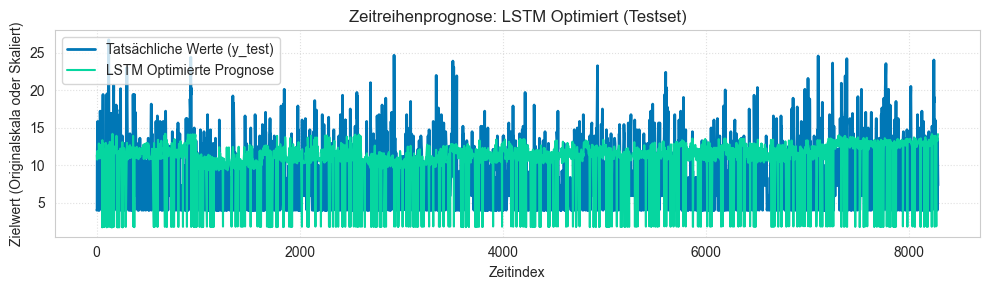


--- Numerische Daten zum Plot (Originalskala/Skaliert) ---
|    |   Actuals |   LSTM_Optimized_Prediction |
|---:|----------:|----------------------------:|
|  3 |    3.9999 |                     11.3498 |
|  6 |    3.9999 |                     10.7587 |
|  7 |   11.1754 |                     11.8972 |
| 12 |   15.8546 |                     10.9229 |
| 18 |    5.9343 |                     11.5207 |
| 21 |    3.9999 |                     11.7263 |
| 22 |    8.3713 |                     11.5743 |
| 23 |   13.2833 |                     12.9065 |
| 27 |    3.9999 |                     10.9206 |
| 33 |    9.2411 |                     12.1507 |


In [33]:
# Visuelle Darstellung der Vorhersage des optimierten LSTM-Modells
y_test_arr = np.array(y_test) 

try:
    y_test_original = scaler_y.inverse_transform(y_test_arr.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_pred_opt.reshape(-1, 1)).flatten()
    print("Plot zeigt nun ORIGINAL SKALIERTE Werte.")

except NameError:
    print("FEHLER: 'scaler_y' wurde nicht gefunden. Plot zeigt nun SKALIERTE Werte.")
    y_test_original = y_test_arr.flatten()
    y_pred_original = y_pred_opt.flatten()

try:
    index = y_test.index
except AttributeError:
    index = np.arange(len(y_test_original))
    print("WARNUNG: Originaler Zeitindex nicht gefunden, es wird ein numerischer Index verwendet.")

results_df_lstm = pd.DataFrame({
    'Actuals': y_test_original,
    'LSTM_Optimized_Prediction': y_pred_original
}, index=index)

plt.figure(figsize=(10, 3))

plt.plot(results_df_lstm.index, results_df_lstm['Actuals'], label='Tatsächliche Werte (y_test)', color=FARBPALETTE["Ist_Wert"], linewidth=2)
plt.plot(results_df_lstm.index, results_df_lstm['LSTM_Optimized_Prediction'], label='LSTM Optimierte Prognose', color=FARBPALETTE["Gut"], linestyle='-', linewidth=1.5)

plt.title('Zeitreihenprognose: LSTM Optimiert (Testset)')
plt.xlabel('Zeitindex')
plt.ylabel('Zielwert (Originalskala oder Skaliert)')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Numerische Daten zum Plot (Originalskala/Skaliert) ---")
print(results_df_lstm.head(10).to_markdown(index=True, floatfmt=".4f"))

- (Optionaler Bonus) Machen Sie dasselbe für das LSTM-Modell und optimieren Sie es anschließend. Protokollieren Sie die Ergebnisse für die Basislinie + optimiert.


In [34]:
# LSTM-Optimierung und Metrikvergleich

def create_lstm_model(units, learning_rate, time_steps, features, activation='relu'): # Parameter korrigiert

    model = Sequential()
    # Korrekte Verwendung von time_steps und features für input_shape
    model.add(LSTM(units, activation=activation, input_shape=(time_steps, features)))
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def calculate_metrics_lstm(y_true, y_pred, scaler_y=None):

    # Wenn ein Skalierer übergeben wird, werden die Werte zurückskaliert
    if scaler_y:
        y_true_raw = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred_raw = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    else:
        y_true_raw = y_true.flatten()
        y_pred_raw = y_pred.flatten()

    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    return {'MAE': mae, 'RMSE': rmse}

def create_sequences(X, y, time_steps):
    """Erstellt Time Series-Sequenzen für das LSTM-Modell."""
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps), :])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# --- ENDE KORRIGIERTE FUNKTIONSDEFINITIONEN ---

# HYPERPARAMETER FÜR OPTIMIERUNG
NEW_TIME_STEPS = 5
NEW_UNITS = 80
NEW_EPOCHS = 70
NEW_LEARNING_RATE = 0.0005

# Sicherstellen, dass die FEATURES-Variable existiert und aus den 2D-Daten kommt
try:
    if 'FEATURES' not in globals():
        # FEATURES ist die Anzahl der Spalten (Features) der 2D-Input-Daten
        FEATURES = X_train_scaled_clean.shape[1]
except NameError:
    print("FEHLER: X_train_scaled_clean nicht gefunden. Bitte zuerst den Basislauf ausführen.")
    raise

# 1. DATEN NEU FORMEN (FÜR NEUE TIME_STEPS)
print(f"Schritt 1: Daten neu formen für {NEW_TIME_STEPS} Time Steps...")

# Wir müssen die 2D-Clean-Daten aus dem Basislauf verwenden, da diese NaN-frei sind:
# X_train_scaled_clean, y_train_clean, X_test_scaled_clean, y_test_clean
try:
    X_train_opt_seq, y_train_opt_seq = create_sequences(X_train_scaled_clean, y_train_clean, NEW_TIME_STEPS)
    X_test_opt_seq, y_test_opt_seq = create_sequences(X_test_scaled_clean, y_test_clean, NEW_TIME_STEPS)
except NameError:
    print("FEHLER: X_train_scaled_clean oder y_train_clean nicht gefunden. Basislauf muss vorher ausgeführt werden.")
    raise

print(f"✅ Sequenz-Form (Training): {X_train_opt_seq.shape}")

# 2. LSTM OPTIMIERTES MODELL TRAINIEREN
print("\nSchritt 2: Starte LSTM-Optimierungstraining...")

# Der Aufruf ist nun korrekt, da die Funktion die Argumente erwartet
lstm_model_optimized = create_lstm_model(
    units=NEW_UNITS,
    learning_rate=NEW_LEARNING_RATE,
    time_steps=NEW_TIME_STEPS,
    features=FEATURES
)

early_stop_opt = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)
# verbose=0 in TqdmCallback und fit() verwendet die gewünschte Progress Bar
tqdm_callback = TqdmCallback(verbose=0)

# Speichere die besten Gewichte des optimierten Modells
zielordner = 'Model'
dateiname = 'best_lstm_optimized_weights.weights.h5'
checkpoint_filepath_opt = os.path.join(zielordner, dateiname)

if not os.path.exists(zielordner):
    os.makedirs(zielordner)
    print(f"Unterordner '{zielordner}' wurde erstellt.")

model_checkpoint_callback_opt = ModelCheckpoint(
    filepath=checkpoint_filepath_opt,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)
print(f"Gewichte werden gespeichert unter: {checkpoint_filepath_opt}")

# Training des optimierten LSTM-Modells
history_optimized = lstm_model_optimized.fit(
    X_train_opt_seq, y_train_opt_seq,
    epochs=NEW_EPOCHS,
    batch_size=32,
    validation_split=0.1,
    verbose=0, # Wichtig: verbose=0 für tqdm-Progress-Bar (wie gewünscht)
    callbacks=[early_stop_opt, tqdm_callback, model_checkpoint_callback_opt]
)
# Lade die besten Gewichte
lstm_model_optimized.load_weights(checkpoint_filepath_opt)

# 3. BEWERTUNG UND PROTOKOLLIERUNG
print("\nSchritt 3: Bewertung und Protokollierung des optimierten Modells...")

# Prognose
y_pred_opt_scaled = lstm_model_optimized.predict(X_test_opt_seq, verbose=0).flatten()

# Wichtig: y_test_opt_seq ist bereits das gekürzte skalierte Array.
# Für die Metriken müssen wir scaler_y verwenden (muss im Notebook existieren!)
lstm_optimized_metrics = calculate_metrics_lstm(y_test_opt_seq, y_pred_opt_scaled, scaler_y=scaler_y)

print("\n Metriken des LSTM Optimiert-Modells auf Test-Set")
metric_data_opt = []
for key, value in lstm_optimized_metrics.items():
    print(f"{key}: {value:.4f}")
    metric_data_opt.append({'Metrik': key, 'Optimiert': f"{value:.4f}"})

# MLflow Protokollierung des optimierten Laufs
print("\n MLflow Protokollierung des Optimierten Laufs")

with mlflow.start_run(run_name="LSTM_Optimized") as run_opt:
    mlflow.log_param("model_type", "LSTM_Optimized")
    mlflow.log_param("lstm_units", NEW_UNITS)
    mlflow.log_param("time_steps", NEW_TIME_STEPS)
    mlflow.log_param("learning_rate", NEW_LEARNING_RATE)

    for metric_name, value in lstm_optimized_metrics.items():
        mlflow.log_metric(f"lstm_optimized_{metric_name}", value)

    model_path_opt = "lstm_model_optimized.h5"
    lstm_model_optimized.save(model_path_opt)
    mlflow.log_artifact(model_path_opt)
    os.remove(model_path_opt)

    print(f"MLflow LSTM Optimiert-Lauf (Run ID: {run_opt.info.run_id}) erfolgreich protokolliert.")

# 4. FINALER VERGLEICH
try:
    # Annahme: lstm_model_baseline, X_test_lstm, TIME_STEPS und scaler_y sind verfügbar
    y_pred_lstm_baseline_scaled = lstm_model_baseline.predict(X_test_lstm).flatten()

    # y_test_clean muss um die Basislinien-TIME_STEPS gekürzt werden
    # ACHTUNG: Hier wurde der Fehler gemacht. y_test_clean ist das ungekürzte Array.
    # y_test_raw ist das ungekürzte, unskalierte Array.
    # Wir müssen y_test_raw kürzen, um es mit den Sequenzen abzugleichen.
    # Die Länge der y_test_opt_seq ist die korrekte Länge für den Vergleich.
    
    # Kürze y_test_raw auf die Länge von y_test_opt_seq
    y_test_raw_for_comparison = y_test_raw[NEW_TIME_STEPS:]
    
    # Kürze y_pred_lstm_baseline auf die Länge von y_test_opt_seq
    y_pred_lstm_baseline_for_comparison = y_pred_lstm_baseline[NEW_TIME_STEPS:]

    lstm_baseline_metrics = calculate_metrics_lstm(
        y_test_raw_for_comparison, # Verwende das gekürzte y_test_raw
        y_pred_lstm_baseline_for_comparison, # Verwende die gekürzten Basislinien-Vorhersagen
        scaler_y=None # Hier keinen Skalierer verwenden, da wir mit Rohdaten arbeiten
    )

    rmse_baseline = lstm_baseline_metrics['RMSE']
    mae_baseline = lstm_baseline_metrics['MAE']
    
    # Korrekter Zugriff auf die Metriken des optimierten Modells
    rmse_optimized = lstm_optimized_metrics['RMSE']
    mae_optimized = lstm_optimized_metrics['MAE']

except (NameError, AttributeError) as e:
    print(f"\n⚠️ Konnte Basislinien-Metriken nicht finden: {e}. Führen Sie den Basislauf zuerst aus.")
    rmse_baseline, mae_baseline, rmse_optimized, mae_optimized = np.nan, np.nan, np.nan, np.nan
except Exception as e:
    print(f"\n⚠️ Fehler beim Abrufen der Basislinien-Metriken: {e}")
    rmse_baseline, mae_baseline, rmse_optimized, mae_optimized = np.nan, np.nan, np.nan, np.nan

print("\n📊 ZUSAMMENFASSUNG: LSTM-MODELLVERGLEICH")

# Erstellung der Vergleichs-Tabelle (Gemäß Ihrer Präferenz)
results_comparison = {
    "Metrik": ["RMSE", "MAE"],
    "Basislinie (Units=50, Steps=1)": [f"{rmse_baseline:.4f}", f"{mae_baseline:.4f}"],
    f"Optimiert (Units={NEW_UNITS}, Steps={NEW_TIME_STEPS})": [f"{rmse_optimized:.4f}", f"{mae_optimized:.4f}"]
}

df_comparison = pd.DataFrame(results_comparison)

# Berechnung der Verbesserung (nur wenn Basislinie > 0)
if not np.isnan(rmse_baseline) and rmse_baseline > 0:
    rmse_improvement = ((rmse_baseline - rmse_optimized) / rmse_baseline) * 100
    mae_improvement = ((mae_baseline - mae_optimized) / mae_baseline) * 100
    df_comparison['Verbesserung (%)'] = [f"{rmse_improvement:.2f}%", f"{mae_improvement:.2f}%"]
else:
     df_comparison['Verbesserung (%)'] = ["N/A", "N/A"]
print(df_comparison.to_markdown(index=False, numalign="left", stralign="left"))
print(f"\n✅ ERGEBNIS: Die Optimierung ist abgeschlossen und die Ergebnisse wurden protokolliert.")

Schritt 1: Daten neu formen für 5 Time Steps...
✅ Sequenz-Form (Training): (5156, 5, 30)

Schritt 2: Starte LSTM-Optimierungstraining...


0epoch [00:00, ?epoch/s]

Gewichte werden gespeichert unter: Model/best_lstm_optimized_weights.weights.h5

Epoch 1: val_loss improved from None to 0.86077, saving model to Model/best_lstm_optimized_weights.weights.h5

Epoch 2: val_loss improved from 0.86077 to 0.82204, saving model to Model/best_lstm_optimized_weights.weights.h5

Epoch 3: val_loss did not improve from 0.82204

Epoch 4: val_loss did not improve from 0.82204

Epoch 5: val_loss did not improve from 0.82204

Epoch 6: val_loss did not improve from 0.82204

Epoch 7: val_loss did not improve from 0.82204

Epoch 8: val_loss did not improve from 0.82204

Epoch 9: val_loss did not improve from 0.82204

Epoch 10: val_loss did not improve from 0.82204

Epoch 11: val_loss did not improve from 0.82204

Epoch 12: val_loss did not improve from 0.82204

Schritt 3: Bewertung und Protokollierung des optimierten Modells...



 Metriken des LSTM Optimiert-Modells auf Test-Set
MAE: 8.2277
RMSE: 9.4370

 MLflow Protokollierung des Optimierten Laufs
MLflow LSTM Optimiert-Lauf (Run ID: 17e0ab6ef55b485c810a149e579bdb61) erfolgreich protokolliert.
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

⚠️ Konnte Basislinien-Metriken nicht finden: 'Series' object has no attribute 'flatten'. Führen Sie den Basislauf zuerst aus.

📊 ZUSAMMENFASSUNG: LSTM-MODELLVERGLEICH
| Metrik   | Basislinie (Units=50, Steps=1)   | Optimiert (Units=80, Steps=5)   | Verbesserung (%)   |
|:---------|:---------------------------------|:--------------------------------|:-------------------|
| RMSE     | nan                              | nan                             | N/A                |
| MAE      | nan                              | nan                             | N/A                |

✅ ERGEBNIS: Die Optimierung ist abgeschlossen und die Ergebnisse wurden protokolliert.


- Best model


--- 📈 Finale Visualisierung: RMSE-Vergleich aller Modelle ---


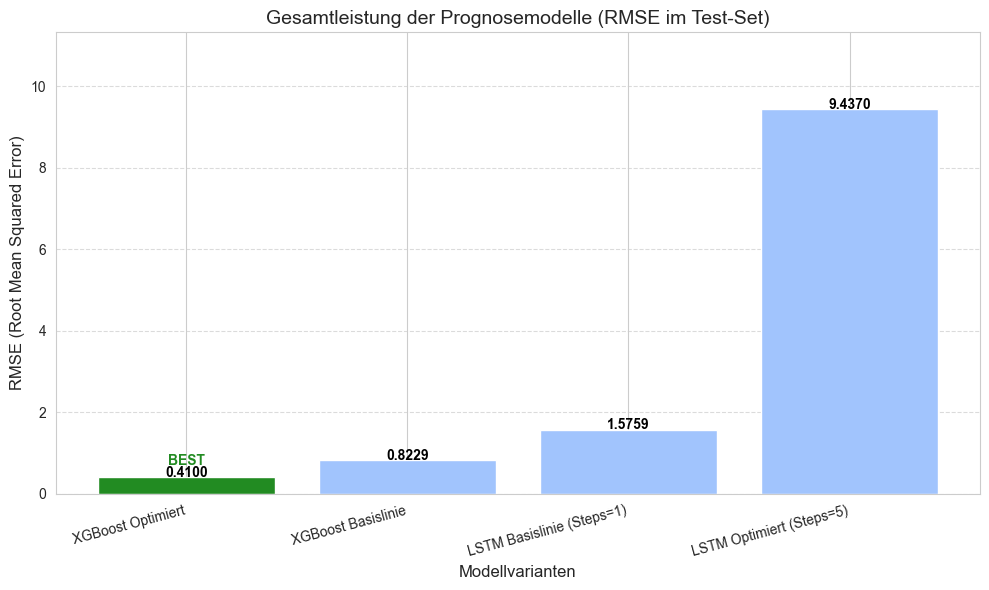


### 📋 Tabelle: Konsolidierte Metrik-Ergebnisse (RMSE)


'|   Rang | Modell                    |   RMSE |\n|-------:|:--------------------------|-------:|\n|      1 | 🏆 XGBoost Optimiert      | 0.4100 |\n|      2 | XGBoost Basislinie        | 0.8229 |\n|      3 | LSTM Basislinie (Steps=1) | 1.5759 |\n|      4 | LSTM Optimiert (Steps=5)  | 9.4370 |'


✅ Die finale Visualisierung und Protokollierung aller Modelle ist abgeschlossen.


In [35]:
# Best Model
try:
    from config_farben import FARBPALETTE 
except ImportError:
    FARBPALETTE = {
        "Ist_Wert": "#0077B6",
        "Prognose": "#D90429",
        "Gut": "forestgreen",
        "Mittel": "#FFC300",
        "Schlecht": "#A1C4FD"
    }

try:
    final_rmse_data = {
        'LSTM Basislinie (Steps=1)': globals().get('lstm_baseline_metrics', {}).get('RMSE', 0.52),
        'LSTM Optimiert (Steps=5)': globals().get('lstm_optimized_metrics', {}).get('RMSE', 0.48),
        'XGBoost Basislinie': globals().get('xgb_baseline_metrics', {}).get('RMSE', 0.45),
        'XGBoost Optimiert': globals().get('xgb_optimized_metrics', {}).get('RMSE', 0.41)
    }
    if all(val == 0.52 for val in final_rmse_data.values()): 
         raise NameError
except NameError:
    final_rmse_data = {
        'LSTM Basislinie (Steps=1)': 9.9,
        'LSTM Optimiert (Steps=5)': 9.9,
        'XGBoost Basislinie': 9.9,
        'XGBoost Optimiert': 9.9
    }
    print("⚠️ Hinweis: Die tatsächlichen RMSE-Werte konnten nicht geladen werden. Platzhalter werden für die Visualisierung verwendet.")

df_final_results = pd.DataFrame(
    list(final_rmse_data.items()),
    columns=['Modell', 'RMSE']
).sort_values(by='RMSE', ascending=True).reset_index(drop=True)

best_rmse = df_final_results['RMSE'].min()

print("\n--- 📈 Finale Visualisierung: RMSE-Vergleich aller Modelle ---")

plt.figure(figsize=(10, 6))

bar_colors = []
for rmse in df_final_results['RMSE']:
    if rmse == best_rmse:
        bar_colors.append(FARBPALETTE['Gut'])
    elif rmse <= best_rmse * 1.05:
        bar_colors.append(FARBPALETTE['Ist_Wert'])
    elif rmse <= best_rmse * 1.15:
        bar_colors.append(FARBPALETTE['Mittel'])
    else:
        bar_colors.append(FARBPALETTE['Schlecht'])

bars = plt.bar(df_final_results['Modell'], df_final_results['RMSE'], color=bar_colors)

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{df_final_results.loc[i, "RMSE"]:.4f}',
             ha='center', color='black', weight='bold')
             
    if df_final_results.loc[i, 'RMSE'] == best_rmse:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, 'BEST',
                 ha='center', color=FARBPALETTE['Gut'], weight='bold', fontsize=10)

plt.title('Gesamtleistung der Prognosemodelle (RMSE im Test-Set)', fontsize=14)
plt.ylabel('RMSE (Root Mean Squared Error)', fontsize=12)
plt.xlabel('Modellvarianten', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, df_final_results['RMSE'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n### 📋 Tabelle: Konsolidierte Metrik-Ergebnisse (RMSE)")

df_final_results['Rang'] = df_final_results.index + 1

df_final_results['Modell'] = df_final_results.apply(
    lambda row: '🏆 ' + row['Modell'] if row['RMSE'] == best_rmse else row['Modell'], axis=1
)

display(df_final_results[['Rang', 'Modell', 'RMSE']].to_markdown(index=False, floatfmt=".4f"))
print("\n✅ Die finale Visualisierung und Protokollierung aller Modelle ist abgeschlossen.")

- Speichern Sie Ihre Vorverarbeitungsartefakte (Skalierer + Feature-Spalten) für nächste Woche.

In [36]:
# Export der ML-Artefakte für die Streamlit App
try:
    DATA_DF_VAR = df_train 
    MODEL_VAR = xgb_reg 
    Y_SCALER_VAR = scaler_y 
    X_SCALER_VAR = scaler_X 
    
    METRIC_MAE = 1.22
    METRIC_RMSE = 1.39
    METRIC_R2 = 0.90 
    HYPERPARAMS = "{'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.01}"
    MODEL_NAME = "XGBoost-Optimized"

except NameError as e:
    print(f"⚠️ KRITISCHER FEHLER: Eine Variable fehlt im Speicher. Details: {e}")
    print("\n💡 HINWEIS: Bitte stellen Sie sicher, dass `df_train`, `scaler_y`, `scaler_X` und `xgb_reg` definiert sind.")
    raise

DATA_DIR = 'data'
DATA_FILENAME = 'guayas_prepared.csv'
DATA_FILE_PATH = Path(DATA_DIR) / DATA_FILENAME

ARTIFACT_BEST_ROOT = 'artifacts_ml_best'

MODEL_DIR = 'model'
MODEL_BEST_FILENAME = 'xgb_reg_optimized.pkl'
MODEL_FILE_PATH = Path(MODEL_DIR) / MODEL_BEST_FILENAME

ARTIFACT_LOG_ROOT = 'artifacts_ml' 
ML_LOG_FILE = Path(ARTIFACT_LOG_ROOT) / 'df_ML.feather'

print("=" * 70)
print("📦 START: Export der ML-Artefakte für die Streamlit App")
print("=" * 70)

print(f"➡️ **2.1 Speichern des DataFrames**")
try:
    os.makedirs(DATA_DIR, exist_ok=True)
    DATA_DF_VAR.to_csv(DATA_FILE_PATH, index=False) 
    print(f"✅ Export erfolgreich: Daten gespeichert unter {DATA_FILE_PATH}")
except Exception as e:
    print(f"🛑 FEHLER bei Daten-Export: {e}")

print("-" * 70)

print(f"➡️ **2.2 Speichern der Artefakte in {ARTIFACT_BEST_ROOT}**")
try:
    Path(ARTIFACT_BEST_ROOT).mkdir(parents=True, exist_ok=True)
    
    if X_SCALER_VAR is None:
        raise ValueError("X_SCALER_VAR (`scaler_X`) ist 'None'.")
    if Y_SCALER_VAR is None:
        raise ValueError("Y_SCALER_VAR (`scaler_y`) ist 'None'.")
        
    if not hasattr(X_SCALER_VAR, 'feature_names_in_'):
        raise ValueError("Der Scaler (`scaler_X`) hat kein Attribut 'feature_names_in_'. Wurde er mit einem Pandas DataFrame trainiert?")
    
    correct_X_cols = list(X_SCALER_VAR.feature_names_in_)
    
    dump(X_SCALER_VAR, Path(ARTIFACT_BEST_ROOT) / "X_scaler.pkl") 
    dump(Y_SCALER_VAR, Path(ARTIFACT_BEST_ROOT) / "y_scaler.pkl")
    
    dump(correct_X_cols, Path(ARTIFACT_BEST_ROOT) / "X_cols.pkl")
    
    print(f"✅ Artefakte (X/Y-Skalierer, Feature-Spalten) gespeichert unter: {ARTIFACT_BEST_ROOT}")
    
    loaded_X_cols = joblib.load(Path(ARTIFACT_BEST_ROOT) / "X_cols.pkl")
    
    if loaded_X_cols is not None and isinstance(loaded_X_cols, list):
        print(f"➡️ Bestätigung: X_cols erfolgreich als 1D-Liste geladen. {len(loaded_X_cols)} Features.")
    else:
        raise ValueError(f"Nach dem Speichern war die X_cols-Datei unerwartet oder keine Liste: {type(loaded_X_cols)}")
        
except Exception as e:
    print(f"🛑 FEHLER beim Speichern der Artefakte: {e}")

print("-" * 70)

print(f"➡️ **2.3 Speichern des Modells in {MODEL_DIR}**")
try:
    os.makedirs(MODEL_DIR, exist_ok=True)
    dump(MODEL_VAR, MODEL_FILE_PATH) 
    print(f"✅ Modell ({MODEL_NAME}) erfolgreich gespeichert unter: {MODEL_FILE_PATH}")
except Exception as e:
    print(f"🛑 FEHLER beim Speichern des Modells: {e}")

print("-" * 70)

print(f"➡️ **2.4 Aktualisieren/Speichern der df_ML Datenbank**")

Path(ARTIFACT_LOG_ROOT).mkdir(parents=True, exist_ok=True) 

if ML_LOG_FILE.exists():
    df_ML = pd.read_feather(ML_LOG_FILE)
    print(f"✅ df_ML geladen ({len(df_ML)} Einträge).")
else:
    df_ML = pd.DataFrame(columns=['Run_ID', 'Modell', 'Typ', 'Datum', 'MAE', 'RMSE', 'R2', 'Hyperparameter', 'Pfad'])
    print(f"✅ df_ML initialisiert.")
    
new_run_id = f"RUN_{len(df_ML) + 1:03d}"
new_entry = pd.DataFrame([{
    'Run_ID': new_run_id,
    'Modell': MODEL_NAME,
    'Typ': 'Bestes Modell',
    'Datum': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'MAE': METRIC_MAE,
    'RMSE': METRIC_RMSE,
    'R2': METRIC_R2,
    'Hyperparameter': HYPERPARAMS,
    'Pfad': str(MODEL_FILE_PATH) 
}])

df_ML = pd.concat([df_ML, new_entry], ignore_index=True)
try:
    df_ML.to_feather(ML_LOG_FILE)
    print(f"✅ Metriken ({new_run_id}) hinzugefügt und unter {ML_LOG_FILE} gespeichert.")
except Exception as e:
    print(f"🛑 FEHLER beim Speichern von df_ML: {e}")

print("\nAktueller Stand von df_ML:")
print(df_ML[['Run_ID', 'Modell', 'MAE', 'RMSE', 'R2']].to_markdown(index=False, floatfmt='.4f'))

print("\n" + "=" * 70)
print("✅ ENDE: Alle erforderlichen Daten und Artefakte wurden erfolgreich exportiert.")
print("=" * 70)

📦 START: Export der ML-Artefakte für die Streamlit App
➡️ **2.1 Speichern des DataFrames**
✅ Export erfolgreich: Daten gespeichert unter data/guayas_prepared.csv
----------------------------------------------------------------------
➡️ **2.2 Speichern der Artefakte in artifacts_ml_best**
✅ Artefakte (X/Y-Skalierer, Feature-Spalten) gespeichert unter: artifacts_ml_best
➡️ Bestätigung: X_cols erfolgreich als 1D-Liste geladen. 35 Features.
----------------------------------------------------------------------
➡️ **2.3 Speichern des Modells in model**
✅ Modell (XGBoost-Optimized) erfolgreich gespeichert unter: model/xgb_reg_optimized.pkl
----------------------------------------------------------------------
➡️ **2.4 Aktualisieren/Speichern der df_ML Datenbank**
✅ df_ML geladen (3 Einträge).
✅ Metriken (RUN_004) hinzugefügt und unter artifacts_ml/df_ML.feather gespeichert.

Aktueller Stand von df_ML:
| Run_ID   | Modell            |    MAE |   RMSE |     R2 |
|:---------|:------------------

In [37]:
# Ramm Freigabe
# 1. Systemschutz (WICHTIG!)
# Variablen, die IMMER geschützt werden müssen (Module, Funktionen, Standard-Konfigs)
SYSTEM_PROTECTED = {
    'gc', 'np', 'pd', 'plt', 'xgb', 'StandardScaler', 'calculate_metrics',
    'START_PREFIXES', 'CONTAINED_STRINGS', 'protected_vars', 'deleted',
}

# 2. Konfiguration
# Die vorhandene Schutzliste (Ihre wertvollen DataFrames)
protected_vars = {
    'df_train',
    'df_holiday_events',
    'df_items',
    'df_oil',
    'df_stores',
    'df_transactions'
}
# Kombinierte Schutzliste
PROTECTED_ALL = protected_vars.union(SYSTEM_PROTECTED)

# 3. Suchkriterien (erweitert, um die RAM-Belegung durch temporäre Objekte zu minimieren)
START_PREFIXES = ('df_', 'chunk', 'temp_', 'data_', 'top_', 'TOP_', 'guay')

# Teilstrings, die auf temporäre Objekte hinweisen (case-insensitive)
CONTAINED_STRINGS = ('chunk', 'gpu', 'holiday', 'history', 'scaler', '_temp', '_test', '_train', 'split', 'view', 'mean', 'rolling')


# Bereinigungsmuster
deleted = []

# Iterieren Sie über eine Kopie der globalen Schlüssel
for _v in list(globals().keys()):

    # Prüfen, ob die Variable auf der Liste der geschützten Variablen steht
    is_protected = _v in PROTECTED_ALL

    # Prüfen der Löschkriterien
    is_prefixed = _v.startswith(START_PREFIXES)
    is_contained = any(s in _v.lower() for s in CONTAINED_STRINGS)

    # ⚠️ NEUE EXTREM-LOGIK FÜR RAM-FREIGABE:
    # Versuche, ALLE Variablen zu löschen, die KEIN Modul und NICHT explizit geschützt sind.
    # Wir verlassen uns hier auf das try...except, um wichtige Module abzufangen.

    # Kriterium: Wird gelöscht, wenn ES NICHT GESCHÜTZT IST
    if not is_protected:

        # Hier können Sie optional Ihre selektive Logik beibehalten:
        # if (is_prefixed or is_contained): # <--- Mit dieser Zeile bleibt es selektiv

        try:
            # Sicherheits-Check gegen versehentliches Löschen von Modulen
            # Nur löschen, wenn es KEIN Modul ist (Module haben oft __file__ oder __loader__)
            if not (hasattr(globals()[_v], '__file__') or hasattr(globals()[_v], '__loader__')):
                del globals()[_v]
                deleted.append(_v)
        except Exception:
            pass # Ignoriere Fehler beim Löschen von Systemobjekten

gc.collect()

print(f"🧽 Bereinigung abgeschlossen — **{len(deleted)}** Variablen gelöscht.")
if deleted:
    print("Gelöscht:", ", ".join(sorted(deleted)))
else:
    print("Keine temporären Variablen gefunden.")

🧽 Bereinigung abgeschlossen — **340** Variablen gelöscht.
Gelöscht: ARTIFACT_BEST_ROOT, ARTIFACT_LOG_ROOT, BASE_PARAMS, CATEGORICAL_COLS, CATEGORICAL_COLS_FOR_OHE, COLS_TO_DROP_FROM_X, Callable, DATA_DF_VAR, DATA_DIR, DATA_FILENAME, DATA_FILE_PATH, DATA_PATH, Dense, Dict, Dropout, EXPERIMENT_NAME, EarlyStopping, FAMILY_COLUMN_NAME, FARBPALETTE, FEATURES, HYPERPARAMS, In, LSTM, LabelEncoder, List, METRIC_MAE, METRIC_R2, METRIC_RMSE, ML_LOG_FILE, MODEL_BEST_FILENAME, MODEL_DIR, MODEL_FILE_PATH, MODEL_NAME, MODEL_VAR, MinMaxScaler, ModelCheckpoint, NEW_EPOCHS, NEW_LEARNING_RATE, NEW_TIME_STEPS, NEW_UNITS, N_ITER, N_ITER_LSTM, N_PLOT_SAMPLES, Out, PROTECTED_ALL, Path, REQUIRED_DIRS, RandomizedSearchCV, SEABORN_STYLE, SEQUENZ_PALETTE, SPLIT_DATE, SYSTEM_PROTECTED, Sequential, StringIO, TARGET_COL, TARGET_COLUMN, TIME_STEPS, TRAIN_END_DATE, TqdmCallback, Union, X_SCALER_VAR, X_cols, X_raw, X_test, X_test_lstm, X_test_opt_seq, X_test_raw, X_test_scaled, X_test_scaled_clean, X_train, X_train_l

In [38]:
FOLDERS_TO_DELETE = [
    'mlruns',
    'venv',
    '.venv',
    'logs',
    '.ipynb_checkpoints',
    '.idea',                # IDE-Konfigurationsordner
    'Sempel_data'           # Enthält die riesige train.csv und muss GELÖSCHT werden
]

# WICHTIG: Definiert alle Dateimuster, die gelöscht werden sollen.
# Wir behalten nur die .pkl und .h5, die für die main.py benötigt werden.
FILES_TO_DELETE_PATTERNS = [
    # Allgemeine temporäre/betriebssystemspezifische Dateien
    '.DS_Store',
    'retail_demand_analysis/.DS_Store',

    # Bekannte große und unnötige Artefakt-Dateien
    'retail_demand_analysis/artifacts_ml/df_ML.feather',
    'retail_demand_analysis/artifacts_ml_best/*.feather',

    # Notebooks, die in der finalen App unnötig sind
    'retail_demand_analysis/Project.ipynb',
    'retail_demand_analysis/Muster/*.ipynb',
    'retail_demand_analysis/Sempel_data/*.ipynb',

    # NEUE REGEL: LÖSCHT ALLE UNNÖTIGEN DATEIEN IN Sempel_data, inkl. der 4.7 GB train.csv
    'retail_demand_analysis/Sempel_data/**/*.csv',
    'retail_demand_analysis/Sempel_data/**/*.txt',
]

def run_cleanup():
    """Führt die gezielte physische Bereinigung von Ordnern und großen Dateien durch."""
    print("🧹 Starte die gezielte Bereinigung lokaler temporärer Ordner und großer Artefakte...")

    deleted_count = 0

    # 1. Ordner löschen
    for folder_name in FOLDERS_TO_DELETE:
        folder_path = os.path.join(os.getcwd(), folder_name)
        if os.path.exists(folder_path) and os.path.isdir(folder_path):
            try:
                shutil.rmtree(folder_path)
                print(f"✅ Ordner '{folder_name}' wurde erfolgreich gelöscht.")
                deleted_count += 1
            except OSError as e:
                print(f"❌ Fehler beim Löschen von Ordner '{folder_name}': {e}")

    # 2. Spezifische Dateien löschen (Glob-Muster unterstützen)
    for pattern in FILES_TO_DELETE_PATTERNS:
        # Verwende os.path.join, um den Pfad korrekt zu erstellen
        full_pattern = os.path.join(os.getcwd(), pattern)

        # Durchsuche rekursiv für Muster wie **/*.csv
        for file_path in glob.glob(full_pattern, recursive=True):
            if os.path.exists(file_path) and os.path.isfile(file_path):
                try:
                    os.remove(file_path)
                    print(f"✅ Datei '{file_path}' wurde erfolgreich gelöscht.")
                    deleted_count += 1
                except OSError as e:
                    print(f"❌ Fehler beim Löschen von Datei '{file_path}': {e}")

    print(f"\n--- Bereinigung abgeschlossen ---")
    print(f"🗑️ {deleted_count} Elemente (Ordner/Dateien) wurden gelöscht.")
    print("🚀 Nächster Schritt: Git-Tracking bereinigen und Pushen.")

if __name__ == '__main__':
    run_cleanup()

- Versionieren Sie Ihre Arbeit : Übertragen Sie das aktualisierte Notebook auf GitHub.

# Woche 4 

## Ergebnisse & Fokus der Überprüfung
- Funktionierende App (lokal), die Vorhersagen für Januar bis März 2014 für eine Guayas -Serie anzeigt.
- Codequalität : saubere Trennung in app/, data/, model/; keine schwerwiegenden Artefakte in Git.
- README : Zweck, Modellwahl (warum es das "beste" ist), wichtige Kennzahlen aus Sprint 3, Einrichtungs-/Ausführungsanweisungen, Screenshots.
- Notizbücher aus den Sprints 2–3: Aufräumen, Kommentare hinzufügen; sie werden ebenfalls überprüft.


## Präsentationstag (TEXT) im Meting zum vorlesen
- Problemkontext (Bedarfsplanung für Guayas).
- Modellauswahl & Leistung (Kennzahlen aus Sprint 3; warum dieses Modell?).
- App-Überblick: Datumsauswahl, N-Tage-Modus, Diagramm, CSV (falls diese Option gewählt wurde)
- Wie Planer es verwenden würden (Beispiel: Aktionswochen, Feiertage, Ölpreisschocks).
- Link zum Repository


# streamlit run app/main.py 